# Who Is the Working Class?

<a id="table-of-contents"></a>

## Table of Contents

1. [Introduction](#introduction)  
2. [Workflow Overview](#workflow-overview)  
   2.1. [Processing a Single Article](#processing-of-a-single-article)  
   2.2. [Applying Workflow to the Full Dataset](#apply)  
3. [Analysis & Results](#analysis-results)  
   3.1. [Geographical Location](#geographical-location)  
   3.2. [Occupations](#occupations)  
   3.3. [Race/Ethnicity](#race-ethnicity)  
   3.4. [Gender](#gender)  
   3.5. [Immigration Status](#immigration-status)  
4. [Conclusion](#conclusion)  
5. [Next Steps](#next-steps)  
6. [Reproducibility](#reproducibility)
7. [Bibliography](#bibliography)


To do:

* Run next batch

* See post-LLM to-do items

* delete all examples when running final notebook

* clean utils.py: which functions actually used in the end?

* conclusion / next steps / reproducibility

* update readme.md

* update requirements.txt

<a id="introduction"></a>
## 1. Introduction 


[⬆ Return to Top](#table-of-contents)

This project analyzes how the working class is represented in the media. It explores changes in representation over time and compares portrayals across different publishers.

In [1]:
# import libraries
import pandas as pd
from datetime import datetime
import os
from statistics import mean, pstdev
from openai import OpenAI
import json
# utils for plots
from utils import compare_histograms, split_locations, flatten, extract_region_mentions, line_time_plot, save_examples_to_folder # review which ones ended up being used
# utils for batch processing
from utils import create_batch, submit_batch, retrieve_batch_results, parse_batch_results
from utils import prepare_batches, run_batch, check_batch, combine_all_batches, batch_data_path
from docx import Document
import re

In [2]:
# code for relaoding
#from importlib import reload
#import utils
#reload(utils)
#from utils import check_batch

In [3]:
# set configurations
#model = "gpt-4.1"
model="gpt-5-mini"
temperature = 1 # Cannot use temperature = 0 with gpt-5-mini (see note below)
reasoning_effort = "minimal"

# Show all columns in all outputs
pd.set_option('display.max_columns', None)

__Note on Temperature:__

- Ideally, we would set the temperature parameter to 0.
- With **full models** (e.g., GPT-4.1, GPT-5), you can set `temperature = 0` for deterministic outputs.  
- With **gpt-5-mini**, the `temperature` parameter is fixed at **1** (the default) and cannot be changed.  
- This is **intentional**: mini models are optimized for **throughput, cost, and speed**. Because their probability distributions are less “sharp” than larger models, forcing `temperature = 0` could cause issues such as repetitive loops, truncated outputs, or overly rigid phrasing.  
- At **temperature = 1**, the model samples directly from its predicted distribution, without sharpening (lower temps) or flattening (higher temps).  


In [4]:
# load cleaned data
df_articles = pd.read_pickle("../data/processed/cleaned_articles.pkl")

print(f"Total number of articles: {df_articles.shape[0]:,}")

Total number of articles: 39,863


In [5]:
def is_article_domestic(section_category, country_flag):
    if section_category in ["Metro/Local", "US/National"]:
        return True
    if section_category == "World/International":
        return False
    if country_flag  != "FOREIGN_ONLY":
        return True
    return False

In [6]:
# domestic articles only
domestic_flag = df_articles.apply(lambda x: is_article_domestic(x['section_category'], x['country_flag']), axis = 1)
df_articles = df_articles.loc[domestic_flag]
print(f"Net number of domestic articles: {df_articles.shape[0]:,}")

Net number of domestic articles: 35,005


In [7]:
# Calculate article length threshold for filtering out anomalously long articles
article_lengths = df_articles["length"]
large_length_threshold = round(mean(article_lengths) + 3 * pstdev(article_lengths))
print(f"Anomalously large article length threshold: {large_length_threshold:,}")

# Filter out anomalously large articles
df_articles = df_articles.loc[df_articles['length'] < large_length_threshold]
print(f"Net number of articles after length filter: {df_articles.shape[0]:,}")

Anomalously large article length threshold: 4,665
Net number of articles after length filter: 34,352


In [8]:
# year
df_articles['year'] = pd.to_datetime(df_articles["date"]).dt.year

In [9]:
df_articles.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category,year
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua]","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times,section a; column 0; national desk; pg. 16,US/National,2024
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),what to know,None,2024
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times,section c; column 0; the arts/cultural desk; p...,Arts/Culture,2024
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,opinion; pg. a13,Opinion/Editorial/Letters,2024
5,"Amy Carter, Thrust Into the Public Eye at a Yo...",New York Times,2024-12-30,US; politics,Jimmy Carter's daughter had an extraordinary a...,1229,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua]","[Massachusetts, Rhode Island, Washington]",NYT/1.DOCX,The New York Times,us; politics,US/National,2024


### Cost Estimate and Reduction Options

#### Baseline Cost

- **200 article sample using GPT-4.1**  

  - $1.05 per 200 articles
  
  - Population size: 37,795 
  
  - Total cost ≈ 37,795 / 200 * $1.05 = **USD 198.42**

- **200 article sample using GPT-5 mini with reasoning_effort = "minimal"**  

  - $0.17 per 200 articles
  
  - Population size: 37,795 
  
  - Total cost ≈ 37,795 / 200 * $0.18 = **USD 34.02**  


---

#### Cost Reduction Options

##### 1. Switch to GPT-5-mini (`reasoning_effort="minimal"`)
- **Pricing (per 1 M tokens)**
  - Input: $0.25
  
  - Cached input: $0.025 
  
  - Output: $2.00 
  
  - Source: https://platform.openai.com/docs/pricing

- **Comparison (GPT-4.1)**
  - Input: $2.00  
  
  - Cached input: $0.5
  
  - Output: $8.00 

- **Performance Reference**  
  [Artificial Analysis Comparison](https://artificialanalysis.ai/?models=gpt-5-mini-minimal%2Cgpt-4-1%2Cgpt-5-mini-medium%2Cgpt-5-nano%2Cgpt-5-mini)

- **Reasoning Effort Levels (GPT-5 series)**
  - Minimal → prioritizes **speed + low cost**, minimal internal reasoning  
  - Medium, High → progressively more reasoning, higher latency + cost  

---

##### 2. Caching
- Looked into caching the **system prompt** and **response_format** to reduce input cost
- Learned that handlend automatically but only applies to larger inputs

---

##### 3. Batch API
- Run tasks asynchronously (up to 24 hours)  
- Saves **50% on inputs and outputs**  
- Docs: [OpenAI Batch API](https://platform.openai.com/docs/guides/batch)  



### Other cost considerations

#### Rate limits

* API usage is subject to rate limits applied on tokens per minute (TPM), requests per minute or day (RPM/RPD), and other model-specific limits.

* Limits: https://platform.openai.com/settings/organization/limits

* Increased to Usage tier 2 by adding \$50 to my account, but likely need Usage tier 3 or above to run all in one batch.

* Reccomendation: Create 8 batches of roughly 5,000 articles each, and run each on separate days. Good also for reducing chances of issues.

<a id="workflow-overview"></a>
## 2. Workflow Overview

[⬆ Return to Top](#table-of-contents)

The goal of this stage of the project is to systematically extract information on key identity domains of the working-class groups described in newspaper articles. Each article is processed to identify and categorize characteristics such as geographical location, occupations, race/ethnicity, gender, education, immigration status, union membership, and other relevant traits. These categories provide a structured representation of how the working class is depicted across different publishers and time periods.

To achieve this, we designed a workflow that converts unstructured text into a consistent, machine-readable format. First, a system prompt instructs the model to focus exclusively on the working class within each article and return answers for the eight domains. The output is constrained by a strict JSON schema, ensuring that all responses are standardized and comparable across articles.

The workflow proceeds in two steps:

1. **Processing a Single Article** – A single news article is passed through the system to validate that the prompt and schema produce accurate, well-structured responses.  
2. **Applying Workflow to the Dataset** – Once validated, the method is applied to a larger, balanced sample of articles across publishers, producing a dataset where each article is paired with its extracted working-class identity attributes.

The processed dataset then forms the basis for the next section, which further analyzes and visualizes patterns in how different publishers and time periods portray the working class.


<a id="processing-of-a-single-article"></a>
### 2.1. Processing a Single Article


[⬆ Return to Top](#table-of-contents)

In [10]:
system_prompt = """
The user will provide a newspaper article that mentions the working class. Using information from this article, answer the following questions **focusing exclusively on the characteristics of the working class group** described. Do not include information about other groups or individuals, even if they interact with or are discussed alongside the working class. If any information is missing or cannot be reasonably inferred, respond with "NA."

1) **Locations** – Where is this working-class group located? 
   - List all relevant U.S. states (or, if outside the U.S., list the countries).
   - If in the U.S., also identify the region (Northeast, Midwest, South, Southwest, or West).
   - Indicate whether the setting is primarily urban, suburban, or rural.

2) **Occupations** – What kinds of jobs does this working-class group hold? (List all that apply.) 
   - Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation.
   - If "Other", please specify. Use “Other” only when job types are known but cannot reasonably fit into any of the categories above.

3) **Race/Ethnicity** – What racial or ethnic backgrounds are identified for this working-class group? Use Census Bureau categories: White, Black or African American, American Indian or Alaska Native, Asian, Native Hawaiian or Other Pacific Islander.

4) **Gender** – What is the gender composition of the working-class group?

5) **Immigration Status** – Determine whether the working-class group includes any immigrants.
   - Output "Immigrant" if at least one individual in the group is an immigrant.
   - Output "Not immigrant" if all individuals are non-immigrants.
   - Output "NA" if there is no information available about the immigration status of the workers.
"""

In [11]:
print(system_prompt)


The user will provide a newspaper article that mentions the working class. Using information from this article, answer the following questions **focusing exclusively on the characteristics of the working class group** described. Do not include information about other groups or individuals, even if they interact with or are discussed alongside the working class. If any information is missing or cannot be reasonably inferred, respond with "NA."

1) **Locations** – Where is this working-class group located? 
   - List all relevant U.S. states (or, if outside the U.S., list the countries).
   - If in the U.S., also identify the region (Northeast, Midwest, South, Southwest, or West).
   - Indicate whether the setting is primarily urban, suburban, or rural.

2) **Occupations** – What kinds of jobs does this working-class group hold? (List all that apply.) 
   - Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation.
   - If "Other", please specify. Use “Ot

In [12]:
response_format = {
  "type": "json_schema",
  "json_schema": {
    "name": "working_class_article_analysis",
    "schema": {
      "type": "object",
      "properties": {
        "locations": {
          "type": "array",
          "description": "List of U.S. states or countries where the working-class group is located. If unclear or not mentioned, return ['NA'].",
          "items": { "type": "string" },
          "minItems": 1
        },
        "us_region": {
          "type": "string",
          "description": "U.S. region of the working-class group (Northeast, Midwest, South, Southwest, West). Use 'NA' if not in the U.S. or unspecified."
        },
        "setting": {
          "type": "string",
          "description": "Urban, Suburban, or Rural setting of the working-class group. Use 'NA' if not stated."
        },
        "occupations": {
          "type": "array",
          "description": "Occupations held by the working-class group. Choose from: Manufacturing, Service, Construction, Administrative/Clerical, Transportation. If other, specify (e.g., 'Other: Agriculture'). If not mentioned, use ['NA'].",
          "items": { "type": "string" },
          "minItems": 1
        },
        "race_ethnicity": {
          "type": "string",
          "description": "Racial or ethnic backgrounds identified for the working-class group (e.g., White, Black or African American, Asian). Use 'NA' if unspecified."
        },
        "gender": {
          "type": "string",
          "description": "Gender composition of the working-class group (e.g., 'Mostly women', 'Mostly men', 'Mixed', or 'NA')."
        },
        "immigration_status": {
          "type": "string",
          "description": "Immigration status of the group. Options: 'Immigrant', 'Not immigrant', 'Undocumented', 'Naturalized citizens', 'Citizens', or 'NA' if unspecified."
        }
      },
      "required": [
        "locations",
        "us_region",
        "setting",
        "occupations",
        "race_ethnicity",
        "gender",
        "immigration_status"
      ],
      "additionalProperties": False
    },
    "strict": True
  }
}


In [13]:
client = OpenAI()

def analyze_working_class(user_prompt):
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        response_format=response_format,
        temperature=temperature,
        reasoning_effort=reasoning_effort
    )

    return json.loads(response.choices[0].message.content)


In [14]:
article_indx = 2
user_prompt = "Title: {}\n\nBody: {}".format(df_articles["title"].iloc[article_indx], df_articles["body"].iloc[article_indx])
print(user_prompt[:2000], "\n...\n")

Title: She Exalted The Beauty Of Dance

Body: She was The New Yorker's first dance critic. Her wit could be devastating but behind it was a belief in beauty.
Arlene Croce, who died last week at 90, made dance as important in arts criticism as painting, music, theater and books. The New Yorker's dance critic from 1973 to 1996, Croce amassed a cult following and not a few detractors. She was also, despite insular origins, one of the most daring and stylish critics in the American canon. 
  In the 1970s, a dance boom hit New York City, and The New Yorker created its first-ever dance critic slot, filling it with a 40-year-old editor and film critic plucked from small-magazine obscurity: Croce.
  But Croce wasn't created by the dance boom. She created herself, through a stubborn, private, almost secret ambition, and a sort of homemade feminism that morphed into an Olympian credo about art. She believed in beauty. And she believed that a mix of virtuosity and classicism -- she loved that wor

In [15]:
response_dict = analyze_working_class(user_prompt)
response_dict

{'locations': ['Rhode Island', 'North Carolina'],
 'us_region': 'Northeast (Rhode Island) and South (North Carolina)',
 'setting': 'Suburban/Urban',
 'occupations': ['Manufacturing'],
 'race_ethnicity': 'White (Italian American)',
 'gender': 'Mixed (family includes men and women)',
 'immigration_status': 'NA'}

<a id="apply"></a>
### 2.2. Applying Workflow to the Full Dataset (Testing with Sample First)


[⬆ Return to Top](#table-of-contents)

Sampling code (for testing):

In [16]:
# n_total = 200 * 35

# df_articles_subset = df_articles.loc[df_articles['year'] >= 1990]# 1990s onward

# # Number of samples per publisher per year
# n_per_group = n_total // (df_articles_subset['publisher'].nunique() * df_articles_subset['year'].nunique())

# # Sample equally by publisher and year
# df_sampled = pd.concat(
#     [
#         group.sample(min(len(group), n_per_group), random_state=42)
#         for _, group in df_articles_subset.groupby(['publisher', 'year'])
#     ]
# )

# df_sampled.reset_index(drop=True, inplace=True)
# print(df_sampled.groupby(['publisher', 'year']).size())

#print(df_sampled.shape) # noted fewer articles in 1990 and 1991 for Other Publishers
#for x, y in df_sampled.groupby(['publisher', 'year']).size().items():
 #   print(x, y)
    
#sample_path = f"../data/processed/df_articles_{n_total}_sample.pkl"
# temporarily save
#if not os.path.exists(sample_path):
 #   df_sampled.to_pickle(sample_path)

In [17]:
import math

# --- CONFIGURATION ---
max_batch_size = 7000
n_batches = math.ceil(df_articles.shape[0] / max_batch_size)
print(n_batches)
BATCH_INFO_FILE = os.path.join(batch_data_path, "batch_info.pkl")

5


In [18]:
if os.path.exists(BATCH_INFO_FILE):
    batch_info = pd.read_pickle(BATCH_INFO_FILE)
    batch_info

In [19]:
dfs, batch_info = prepare_batches(df_articles, n_batches, BATCH_INFO_FILE)

⚠️ ../data/processed/batch_data/batch_info.pkl already exists. Loading existing batch definitions.


In [20]:
batch_to_run = 2
run_batch(
    batch_to_run=batch_to_run,
    system_prompt=system_prompt,
    response_format=response_format,
    model=model,
    temperature=temperature,
    reasoning_effort=reasoning_effort,
    client=client, 
    BATCH_INFO_FILE = BATCH_INFO_FILE
)

🚀 Running batch 2 with 6870 rows
⚠️ Output already exists for batch 2. Skipping submission. Batch ID: batch_68f6627cb474819094deac8f13df0f2e


In [21]:
check_batch(2, BATCH_INFO_FILE, model)

Batch status: completed
Results arlready downloaded.
=== Token Usage Summary ===
Prompt tokens:     15610488
Completion tokens: 471048
Cached tokens:     0
Total tokens:      16081536
Estimated cost for gpt-5-mini: $2.4224
✅ Saved merged results to ../data/processed/batch_data/batch_2_results.pkl
🗂️ Updated batch_info.pkl


In [22]:
batch_info = pd.read_pickle(BATCH_INFO_FILE)
batch_info

,batch_number,n_rows,status,batch_id,input_file,output_file,result_file
0,1,6870,completed,batch_68f57350fc7081909068d36e69eb5d65,../data/processed/batch_data/batch_1_input.jsonl,../data/processed/batch_data/batch_1_output.jsonl,../data/processed/batch_data/batch_1_results.pkl
1,2,6870,completed,batch_68f6627cb474819094deac8f13df0f2e,../data/processed/batch_data/batch_2_input.jsonl,../data/processed/batch_data/batch_2_output.jsonl,../data/processed/batch_data/batch_2_results.pkl
2,3,6870,pending,None,../data/processed/batch_data/batch_3_input.jsonl,../data/processed/batch_data/batch_3_output.jsonl,../data/processed/batch_data/batch_3_results.pkl
3,4,6870,pending,None,../data/processed/batch_data/batch_4_input.jsonl,../data/processed/batch_data/batch_4_output.jsonl,../data/processed/batch_data/batch_4_results.pkl
4,5,6872,pending,None,../data/processed/batch_data/batch_5_input.jsonl,../data/processed/batch_data/batch_5_output.jsonl,../data/processed/batch_data/batch_5_results.pkl


In [23]:
df_articles_with_results = combine_all_batches(BATCH_INFO_FILE)
df_articles_with_results.shape

✅ Combined 2 completed batches


(13740, 28)

In [24]:
df_articles_with_results.head(2)

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category,year,batch_number,custom_id,prompt_tokens,completion_tokens,cached_tokens,total_tokens,locations,us_region,setting,occupations,race_ethnicity,gender,immigration_status
0,Increasing Rate Of Foreclosures Upsets Atlanta,New York Times,2007-07-09,Section A; Column 0; Business/Financial Desk; ...,"Despite a vibrant local economy, Atlanta homeo...",1528,False,US_ONLY,[],"[California, Georgia, Louisiana, Michigan, Mis...",NYT/46.DOCX,The New York Times,section a; column 0; business/financial desk; ...,Business/Finance,2007,1,req-0,2782,68,0,2850,[Georgia],South,Urban and Suburban,"[Service, Construction, Transportation, Manufa...",NA,NA,NA
1,Figure skating; FIVE MYTHS,Other publisher,2018-02-18,; Pg. wapo23,Mirai Nagasu performs Monday at the Winter Gam...,880,False,BOTH,"[Korea, Male (Capital)]",[Washington],Other publishers/Files (500) (6).DOCX,Dayton Daily News (Ohio),; pg. wapo23,None,2018,1,req-1,1883,64,0,1947,[Massachusetts],Northeast,Suburban,"[Other: Welder, Other: Homemaker]",NA,Mixed,NA


<a id="analysis-results"></a>
## 3. Analysis & Results

[⬆ Return to Top](#table-of-contents)

This section examines how different aspects of working-class identity are represented across publishers and over time. For each domain, we build on the earlier results, applying additional processing to highlight variation in coverage between *The New York Times* (NYT) and a group of regional publishers, as well as temporal trends.  

The regional publishers included in this combined set are: *Chicago Daily Herald*, *Dayton Daily News*, *Pittsburgh Post-Gazette*, *Star Tribune*, *The Philadelphia Inquirer*, and *USA Today*.  

Each domain section presents descriptive plots and commentary to illustrate both cross-publisher comparisons and changes over time.  


<a id="geographical-location"></a>  
### 3.1. Geographical Location  

[⬆ Return to Top](#table-of-contents)  

**Description:** Identifies where the working-class group is located.  
- List all relevant U.S. states (or, if outside the U.S., list the countries).  
- If in the U.S., also specify the region (Northeast, Midwest, South, Southwest, or West).  
- Indicate whether the setting is primarily *urban, suburban,* or *rural*.  

**Variables:** `location`, `us_region`, `setting`  

---

#### Data Processing Steps  

- **Standardization of location data:**  
  - The raw location field contains either:  
    - Country or countries (for groups outside the U.S.)  
    - State(s) (for U.S.-based groups)  
    - Occasionally additional location details (e.g., city names), from which state or country can sometimes be inferred.  
  - Standardized states and countries were extracted using programmatic keyword searches.  
    - **Limitation:** If only a city (e.g., *Los Angeles*) is mentioned, the algorithm may fail to identify the state (*California*) or country (*U.S.*).  
    - **Opportunity:** A secondary model could improve coverage by mapping additional information.

- **Deriving U.S. region and setting:**  
  - Standardized `us_region` (Northeast, Midwest, South, Southwest, West) and `setting` (urban/suburban/rural) values were generated from raw fields using keyword-based rules.  
  - Initial spot checks show this approach is effective, but full validation is still needed.  

- **Creation of a “Flat” column:**  
  - Based on standardized columns (`countries_stand` --> `countries_stand_flat`, `states_stand` --> `states_stand_flat`, `us_region_stand` --> `us_region_stand_flat`, `setting_stand` --> `setting_stand_flat`) .  
  - Lists were collapsed into single values using the following rules:  
    - **Single value:** The value is retained.  
    - **Multiple values:** Marked as *Mixed*.  
    - **No values:** Marked as *Unspecified*.  


In [25]:
new_cols = pd.DataFrame(list(df_articles_with_results["locations"].apply(split_locations)), columns=['states_stand', 'countries_stand', 'other_locations_stand'])
df_articles_with_results = pd.concat([df_articles_with_results, new_cols], axis=1)

# country correction
df_articles_with_results['countries_stand'] = [["United States"] if (len(state_list) > 0 and country_list == []) else country_list  for state_list, country_list in zip(df_articles_with_results['states_stand'], df_articles_with_results['countries_stand']) ]

In [26]:
# standardize regions
df_articles_with_results['us_region_stand'] = df_articles_with_results['us_region'].apply(extract_region_mentions)

# standardize urban vs rural setting

settings = ['urban', 'suburban', 'rural']
df_articles_with_results['setting_stand'] = df_articles_with_results['setting'].apply(lambda x: [i.title() for i in extract_region_mentions(x.lower(), regions= settings)])


In [27]:
for col in ["countries_stand", "states_stand", "us_region_stand", "setting_stand"]:
    df_articles_with_results[f"{col}_flat"] = df_articles_with_results[col].apply(
        lambda x: "Multiple" if len(x) > 1 else ("Unspecified" if len(x) == 0 else x[0])
    )


In [28]:
df_articles.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category,year
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua]","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times,section a; column 0; national desk; pg. 16,US/National,2024
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),what to know,None,2024
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times,section c; column 0; the arts/cultural desk; p...,Arts/Culture,2024
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,opinion; pg. a13,Opinion/Editorial/Letters,2024
5,"Amy Carter, Thrust Into the Public Eye at a Yo...",New York Times,2024-12-30,US; politics,Jimmy Carter's daughter had an extraordinary a...,1229,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua]","[Massachusetts, Rhode Island, Washington]",NYT/1.DOCX,The New York Times,us; politics,US/National,2024


#### Country-Level Representation

In [29]:
nyt_mask = df_articles_with_results["publisher"] == "New York Times"
nyt_series = df_articles_with_results[nyt_mask]['countries_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['countries_stand_flat']

In [30]:
nyt_series = [i if i in ["United States", "Multiple", "Unspecified"] else "Foreign Country" for i in nyt_series]
other_series = [i if i in ["United States", "Multiple", "Unspecified"] else "Foreign Country" for i in other_series]

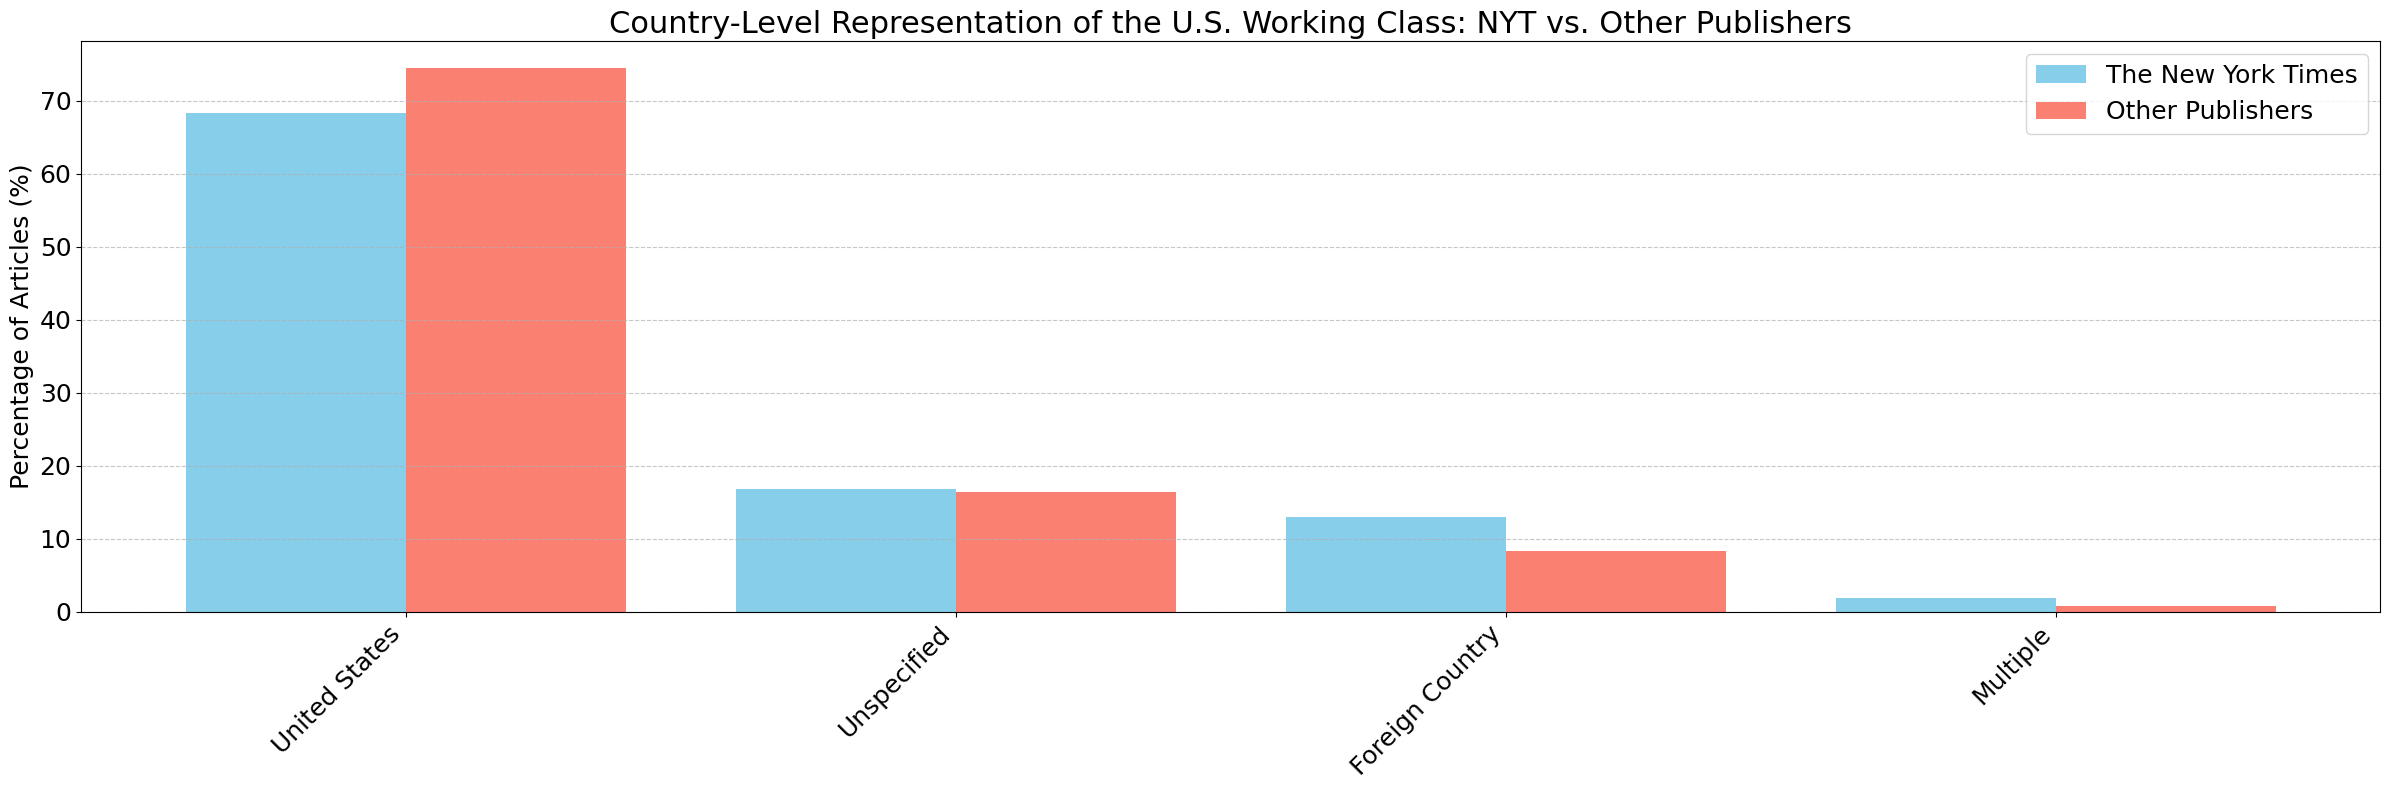

In [31]:
title = 'Country-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_countries.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [32]:
# Base folder path
examples_dir = "../example_articles"

# 1️⃣ Check if "example_articles" folder exists; if not, create it
if not os.path.exists(examples_dir):
    os.makedirs(examples_dir)

var = 'countries_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir, 'locations')

✅ Articles saved successfully.


#### State-Level Representation

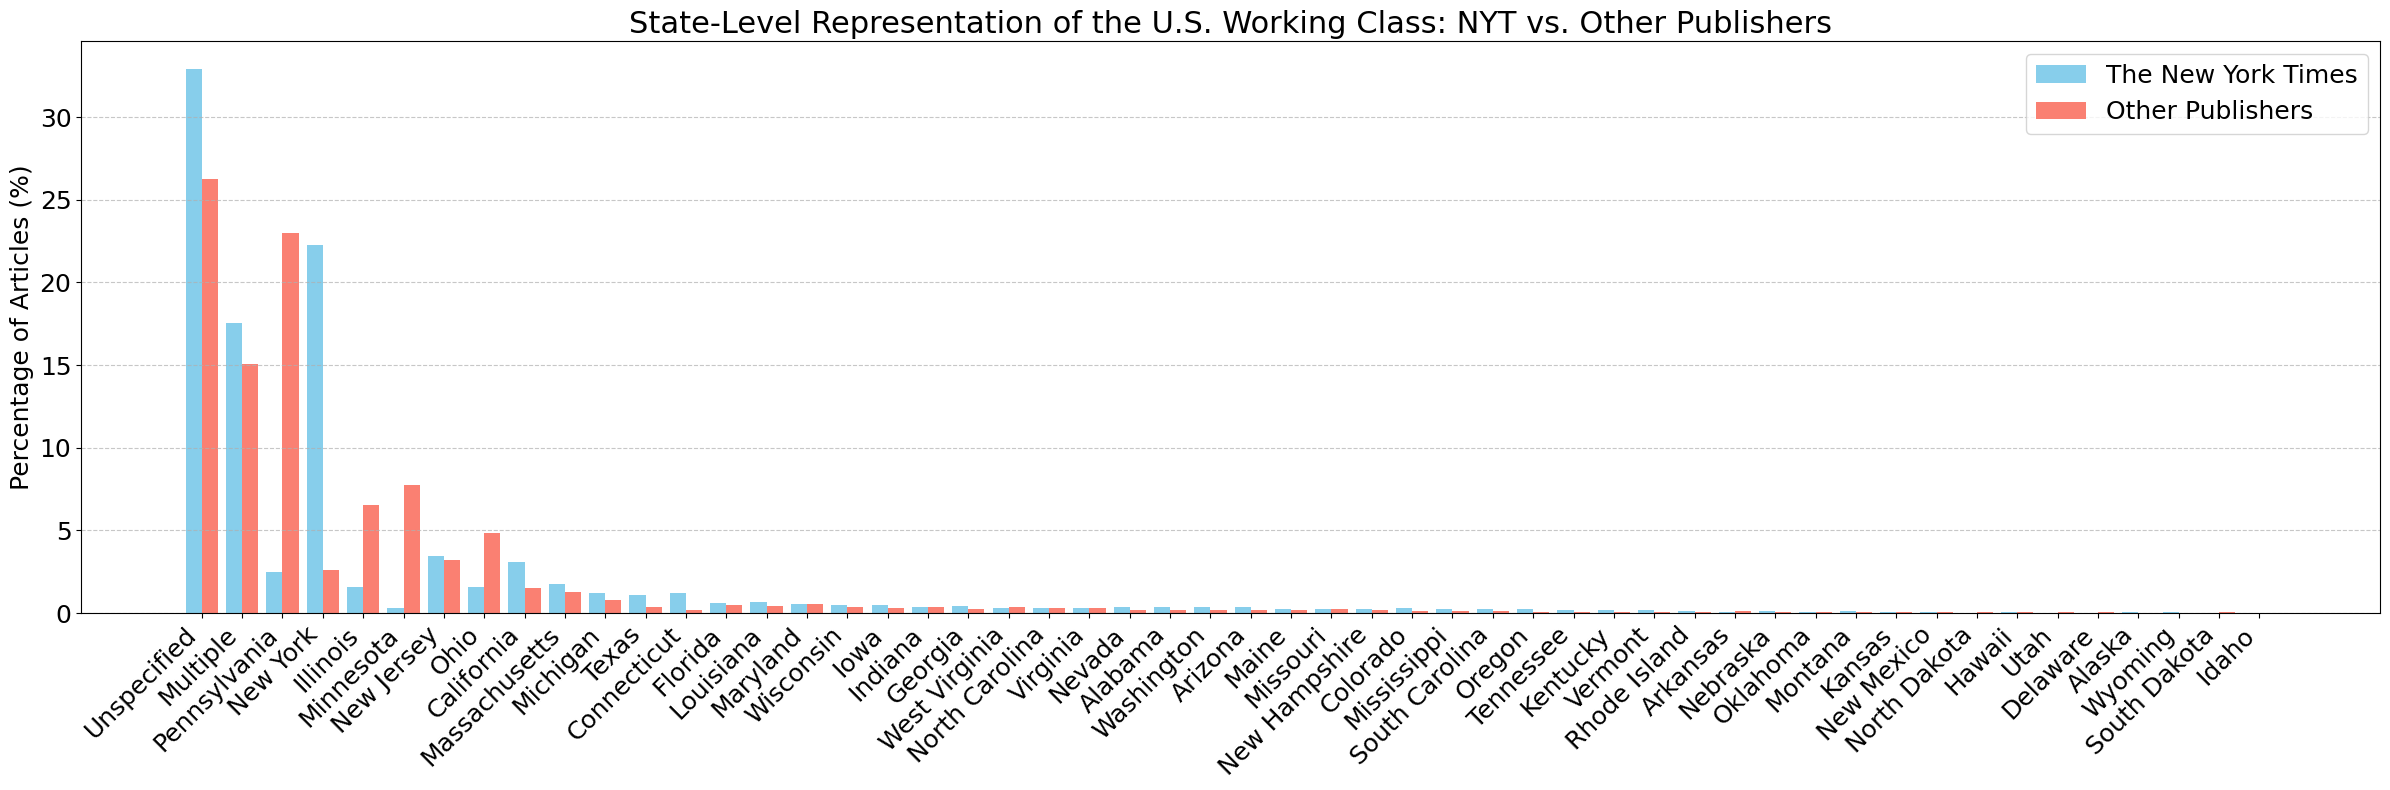

In [33]:
nyt_series = df_articles_with_results[nyt_mask]['states_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['states_stand_flat']

title = 'State-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_states.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [34]:
var = 'states_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir, 'locations')

✅ Articles saved successfully.


In [35]:
from collections import Counter

state_counts = Counter(list(nyt_series) + list(other_series))
high_freq_states = {key: value for key, value in state_counts.items() if value >= 250}
high_freq_states

{'Unspecified': 4170,
 'New York': 2020,
 'Ohio': 390,
 'Multiple': 2283,
 'New Jersey': 462,
 'California': 340,
 'Illinois': 478,
 'Pennsylvania': 1429,
 'Minnesota': 434}

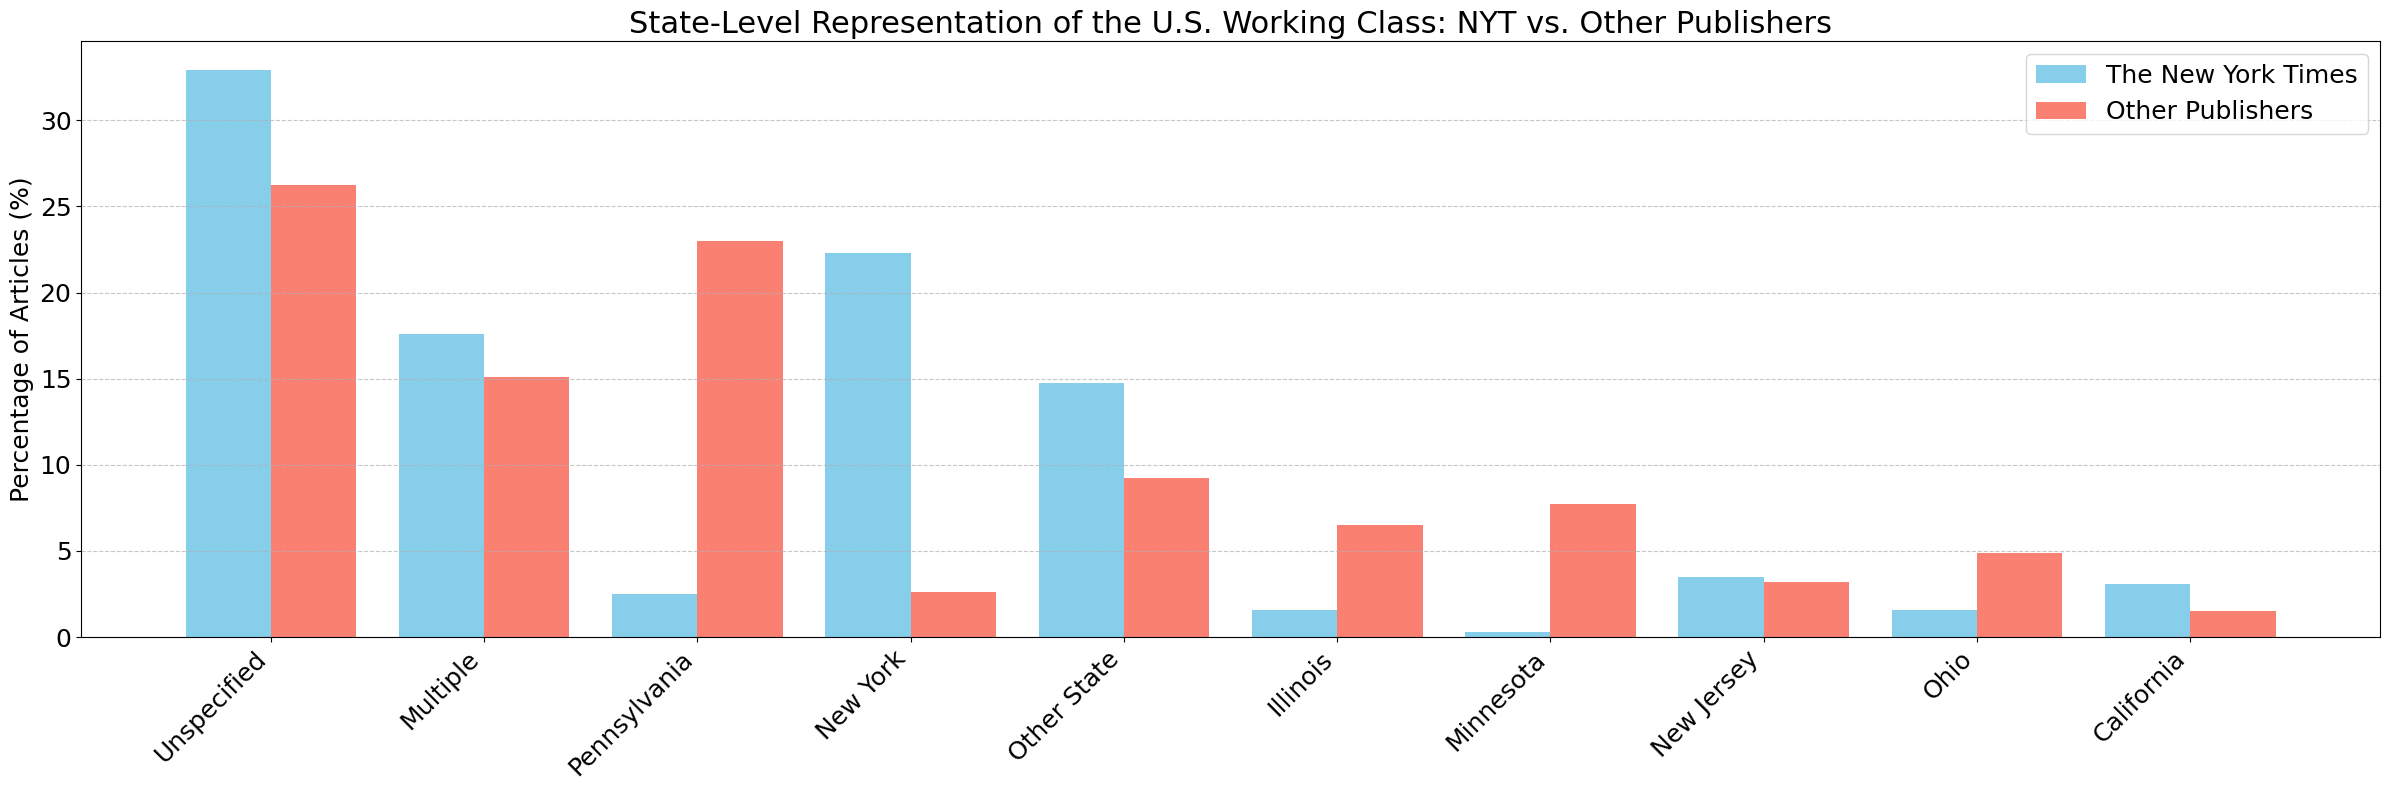

In [36]:
df_articles_with_results["states_stand_flat_cat"] = df_articles_with_results["states_stand_flat"].apply(lambda x: x if x in high_freq_states.keys() else "Other State" )

nyt_series = df_articles_with_results[nyt_mask]['states_stand_flat_cat']
other_series = df_articles_with_results[~nyt_mask]['states_stand_flat_cat']

title = 'State-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_states_categorized.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

In [38]:
#year_mask = df_articles_with_results["year"] > 1991

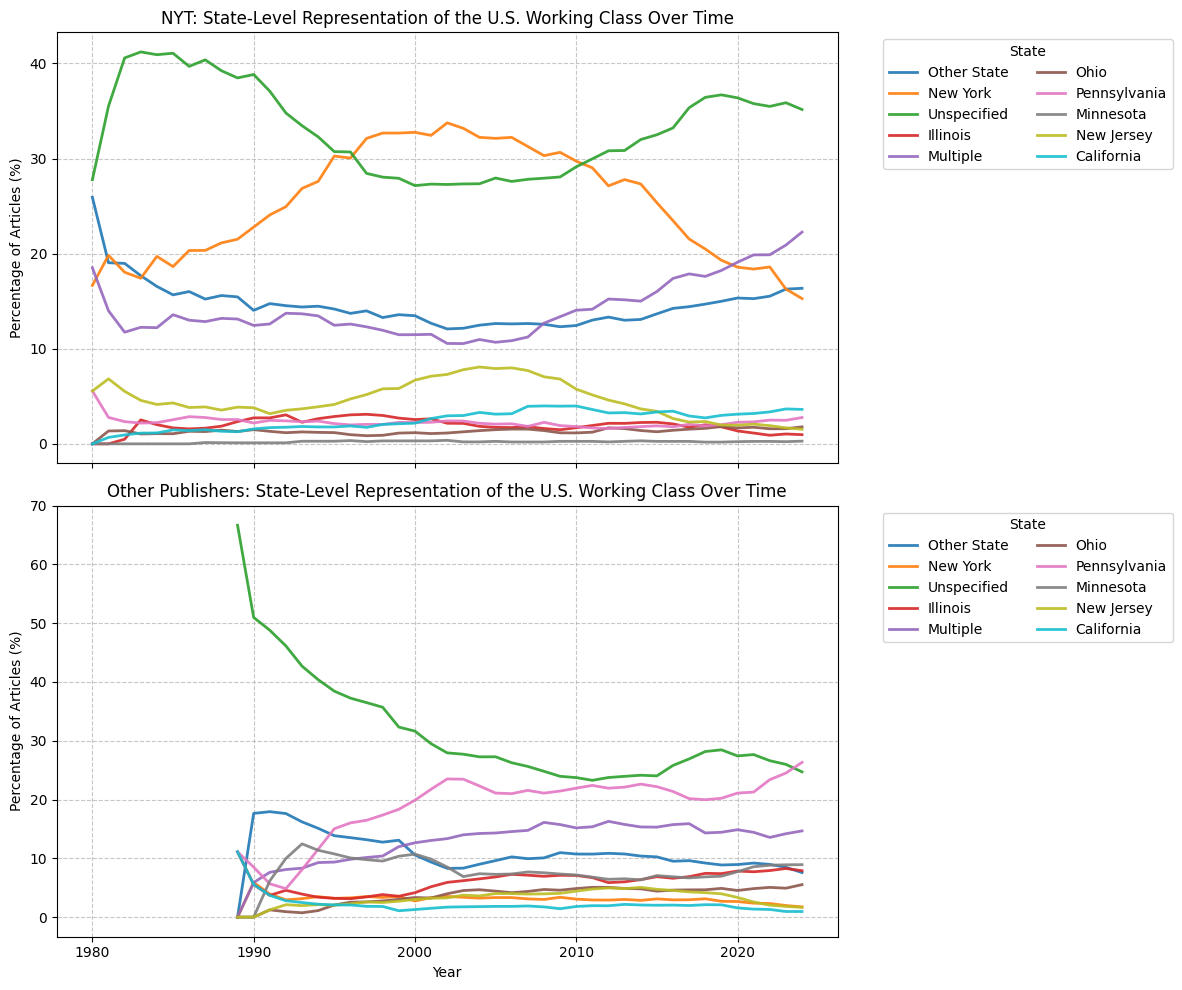

In [39]:
variable = "states_stand_flat_cat"
filename = "../plots/comparison_states_categorized_time_chart.png"
title = 'State-Level Representation of the U.S. Working Class Over Time'
line_time_plot(df_articles_with_results, nyt_mask, variable, title, filename, variable_label="State", smooth_window=10)
#line_time_plot(df_articles_with_results[year_mask], nyt_mask[year_mask], variable, title, filename, variable_label="State", smooth_window=10)

#### Region-level Representation

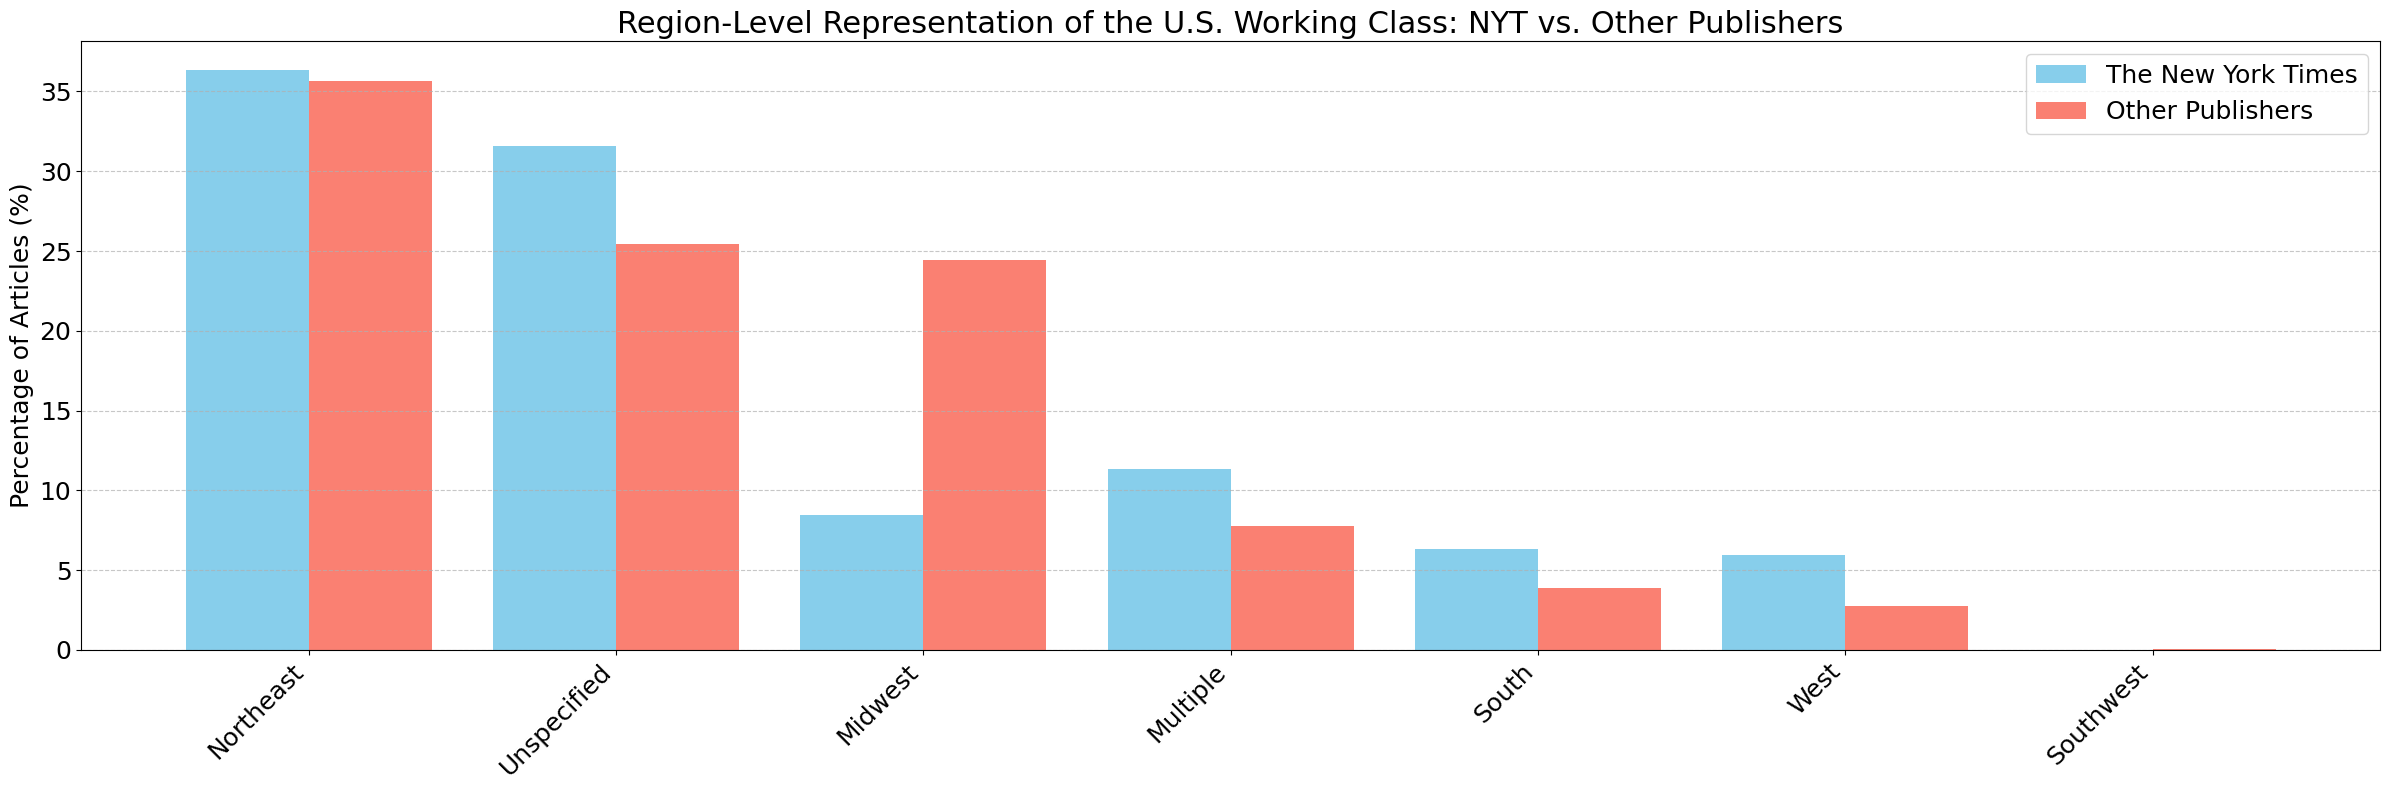

In [40]:
nyt_series = df_articles_with_results[nyt_mask]['us_region_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['us_region_stand_flat']

title = 'Region-Level Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_regions.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [41]:
var = 'us_region_stand_flat'

save_examples_to_folder(var, df_articles_with_results, examples_dir, "locations")

✅ Articles saved successfully.


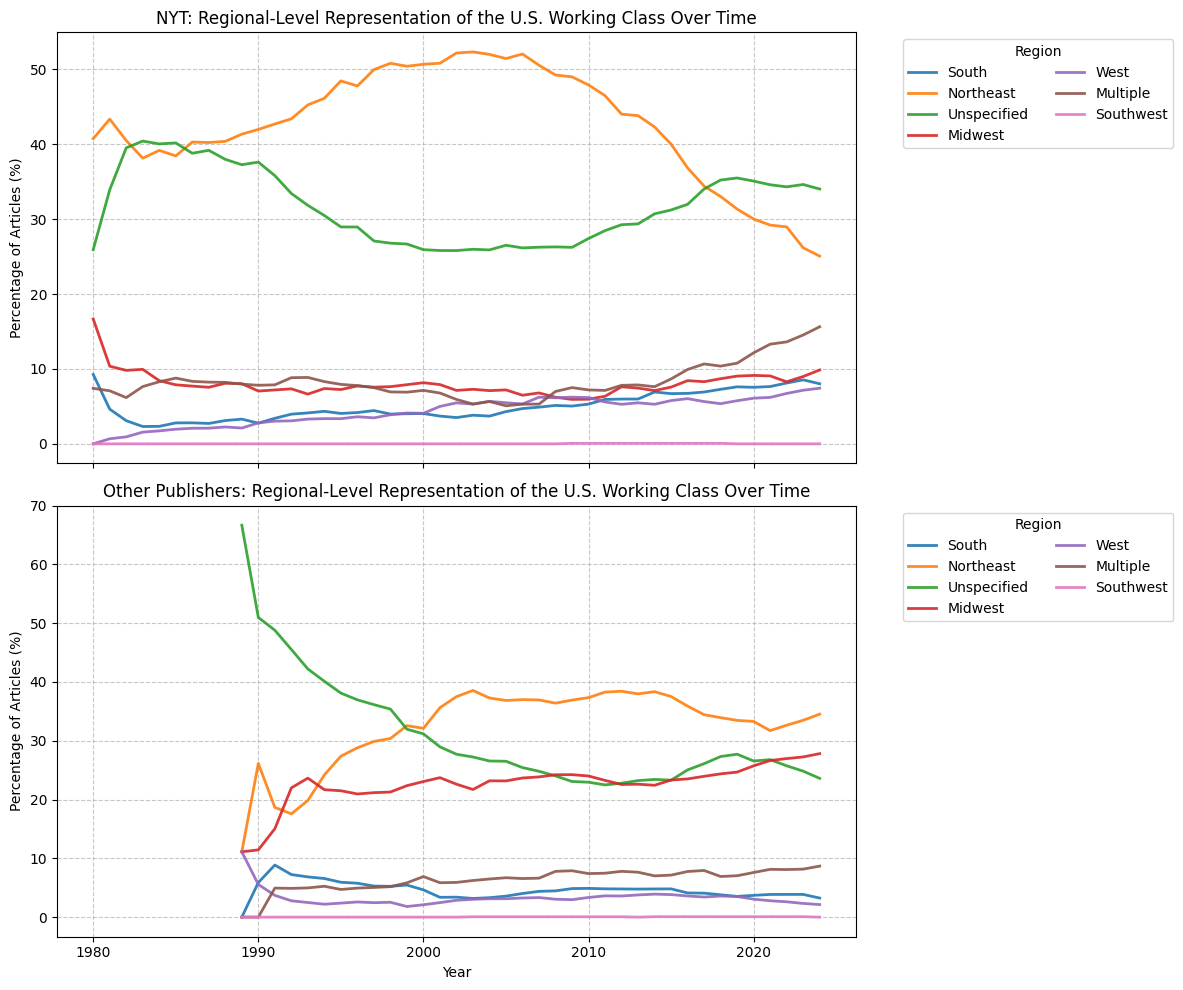

In [42]:
variable = 'us_region_stand_flat'
filename = "../plots/comparison_regions_time_chart.png"
title = 'Regional-Level Representation of the U.S. Working Class Over Time'
line_time_plot(df_articles_with_results, nyt_mask, variable, title, filename, variable_label="Region", smooth_window=10)

#### Urban, Suburban, and Rural Representation

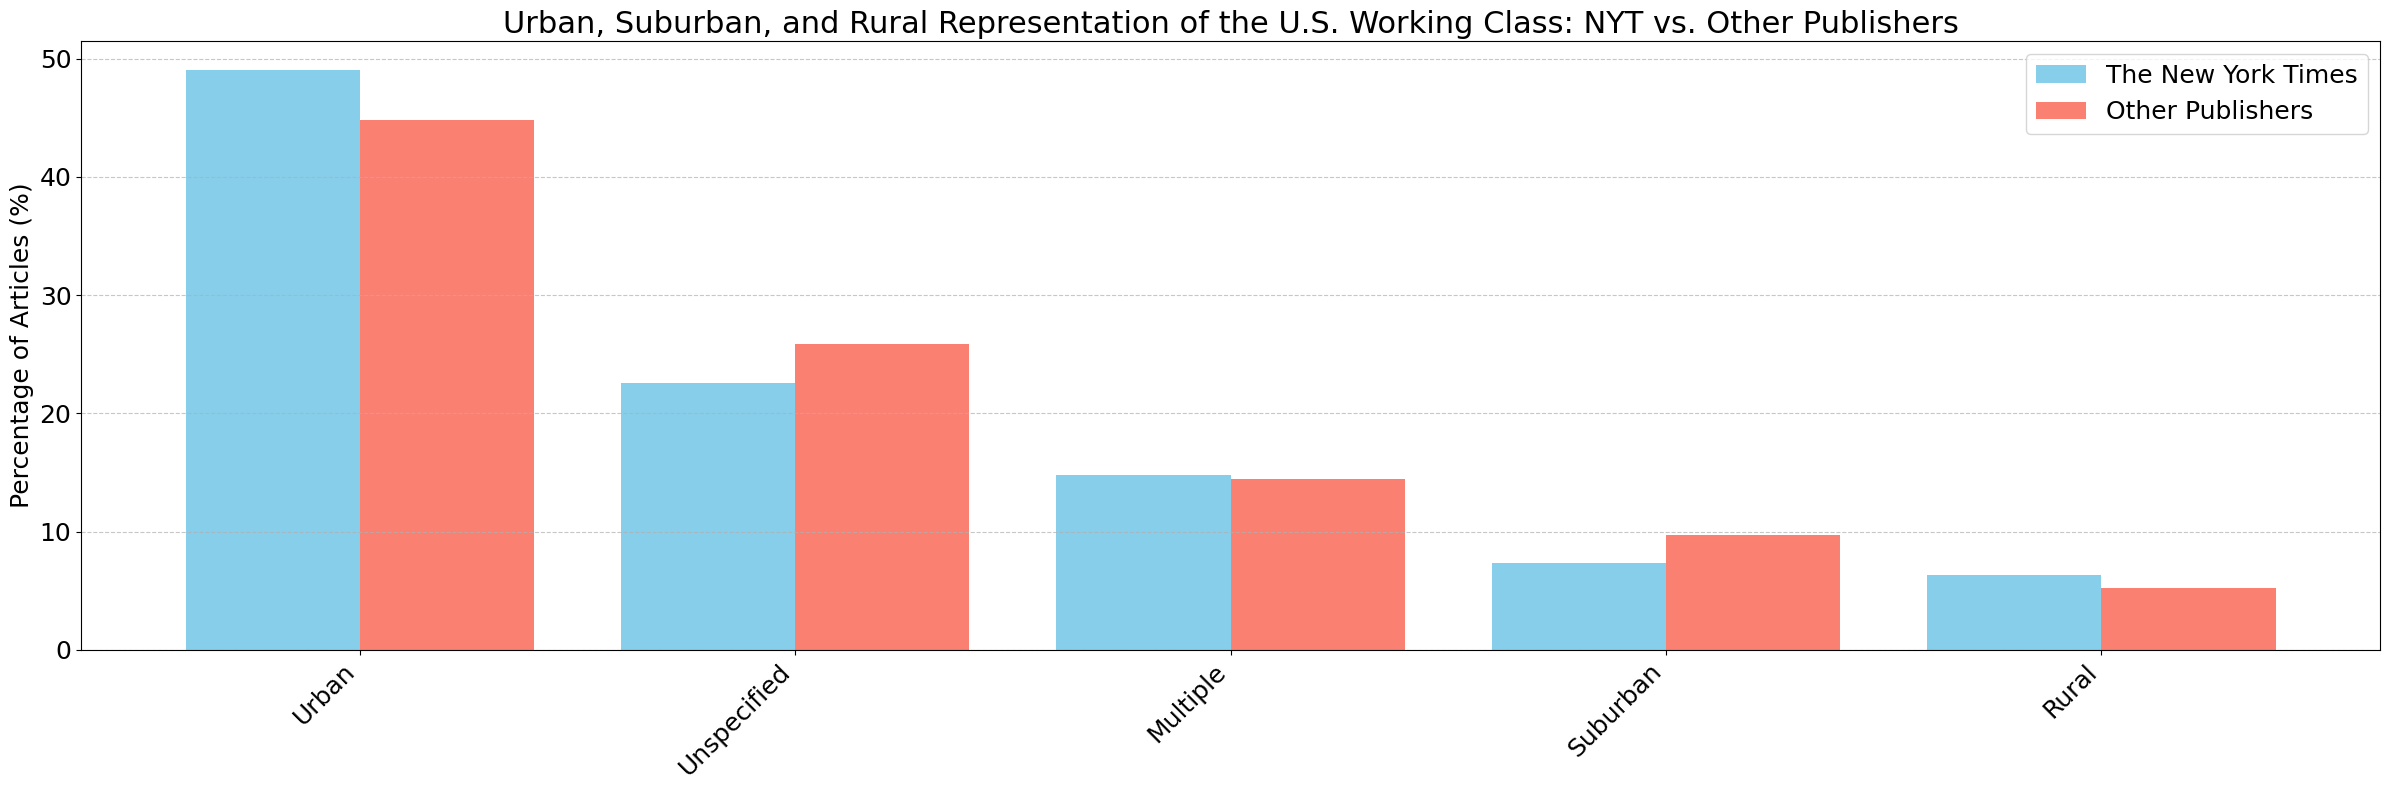

In [43]:
nyt_series = df_articles_with_results[nyt_mask]['setting_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['setting_stand_flat']

title = 'Urban, Suburban, and Rural Representation of the U.S. Working Class: NYT vs. Other Publishers'
filename = "../plots/comparison_location_setting.png"
compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [44]:
var = 'setting_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir, 'locations')

✅ Articles saved successfully.


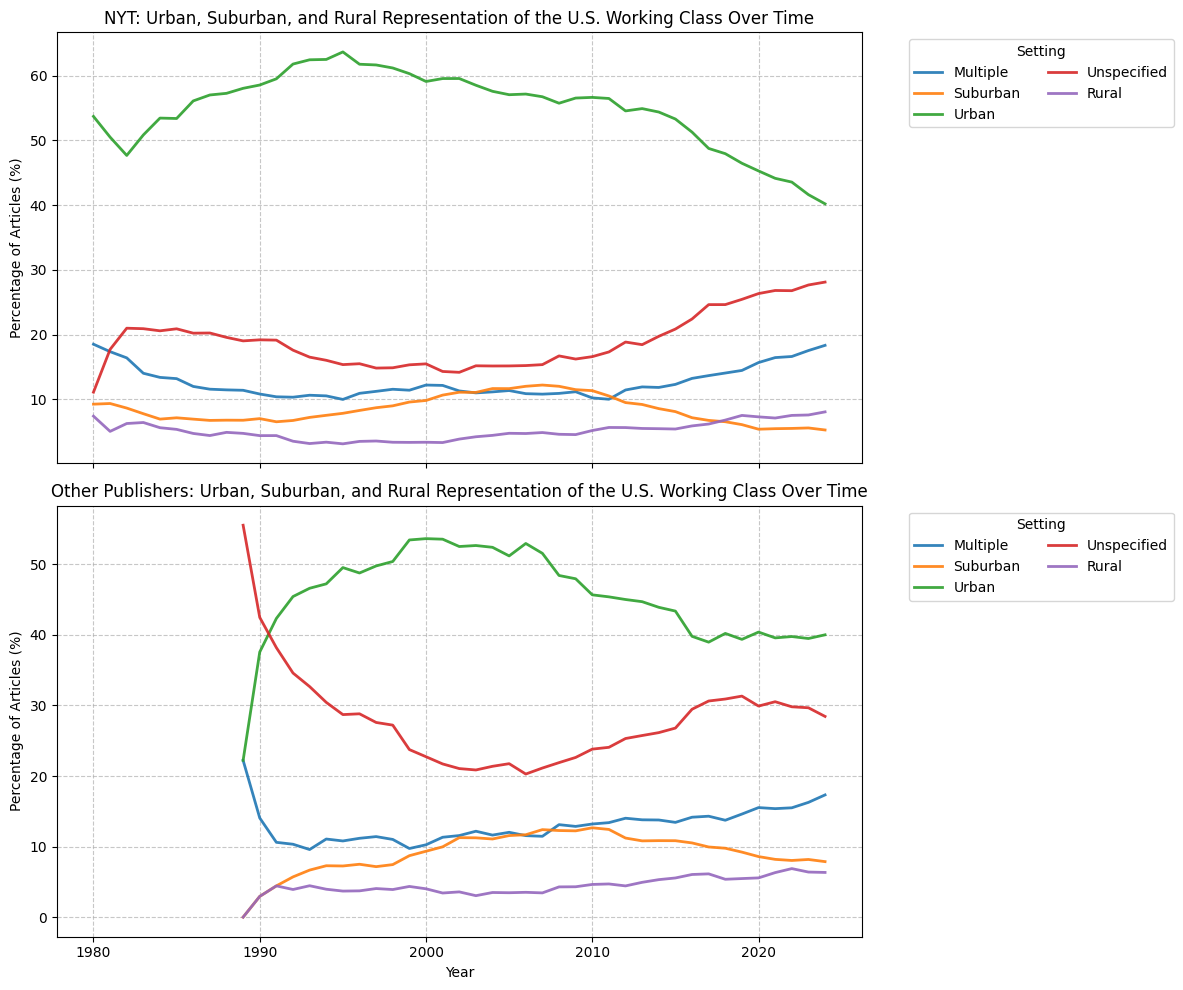

In [45]:
variable = 'setting_stand_flat'
filename = "../plots/comparison_setting_time_chart.png"
title = 'Urban, Suburban, and Rural Representation of the U.S. Working Class Over Time'
line_time_plot(df_articles_with_results, nyt_mask, variable, title, filename, variable_label="Setting", smooth_window=10)

<a id="occupations"></a>
### 3.2. Occupations  

[⬆ Return to Top](#table-of-contents) 

**Occupations** – What kinds of jobs does this working-class group hold? (List all that apply.) 
   - Categories: Manufacturing, Service, Construction, Administrative/Clerical, Transportation.
   - If "Other", please specify.

**Employment Type** – Are members of this working-class group primarily **self-employed (business owners)** or **employees**? If not specified, enter "NA."

#### Occupation sector

In [46]:
occupation_categories = ['Service', 'Manufacturing', 'Construction', 'Administrative/Clerical', 'Transportation']

In [47]:
def standardize_occupation(values_list, categories):
    stand_list = []
    if values_list == ["NA"]:
        return []
    for value in values_list:
        cat_found = False
        for cat in categories:
            if cat.lower() in value.lower():
                stand_list.append(cat)
                cat_found = True
                break
                
        if not cat_found:
            if "administrative" in value.lower() or "clearical" in value.lower():
                stand_list.append('Administrative/Clerical')
            elif "unspecified" not in value.lower() and "no specific" not in value.lower() and "general" not in value.lower() and "not specific" not in value.lower():
                stand_list.append("Other")
    return list(set(stand_list))

def flatten_column(stand_values):
    if len(stand_values) > 1:
        return "Multiple"
    if len(stand_values) == 0:
        return "Unspecified"
    return stand_values[0]

In [48]:
df_articles_with_results["occupations_stand"] = df_articles_with_results["occupations"].apply(lambda x: standardize_occupation(x, occupation_categories))
df_articles_with_results["occupations_stand_flat"] = df_articles_with_results["occupations_stand"].apply(flatten_column)

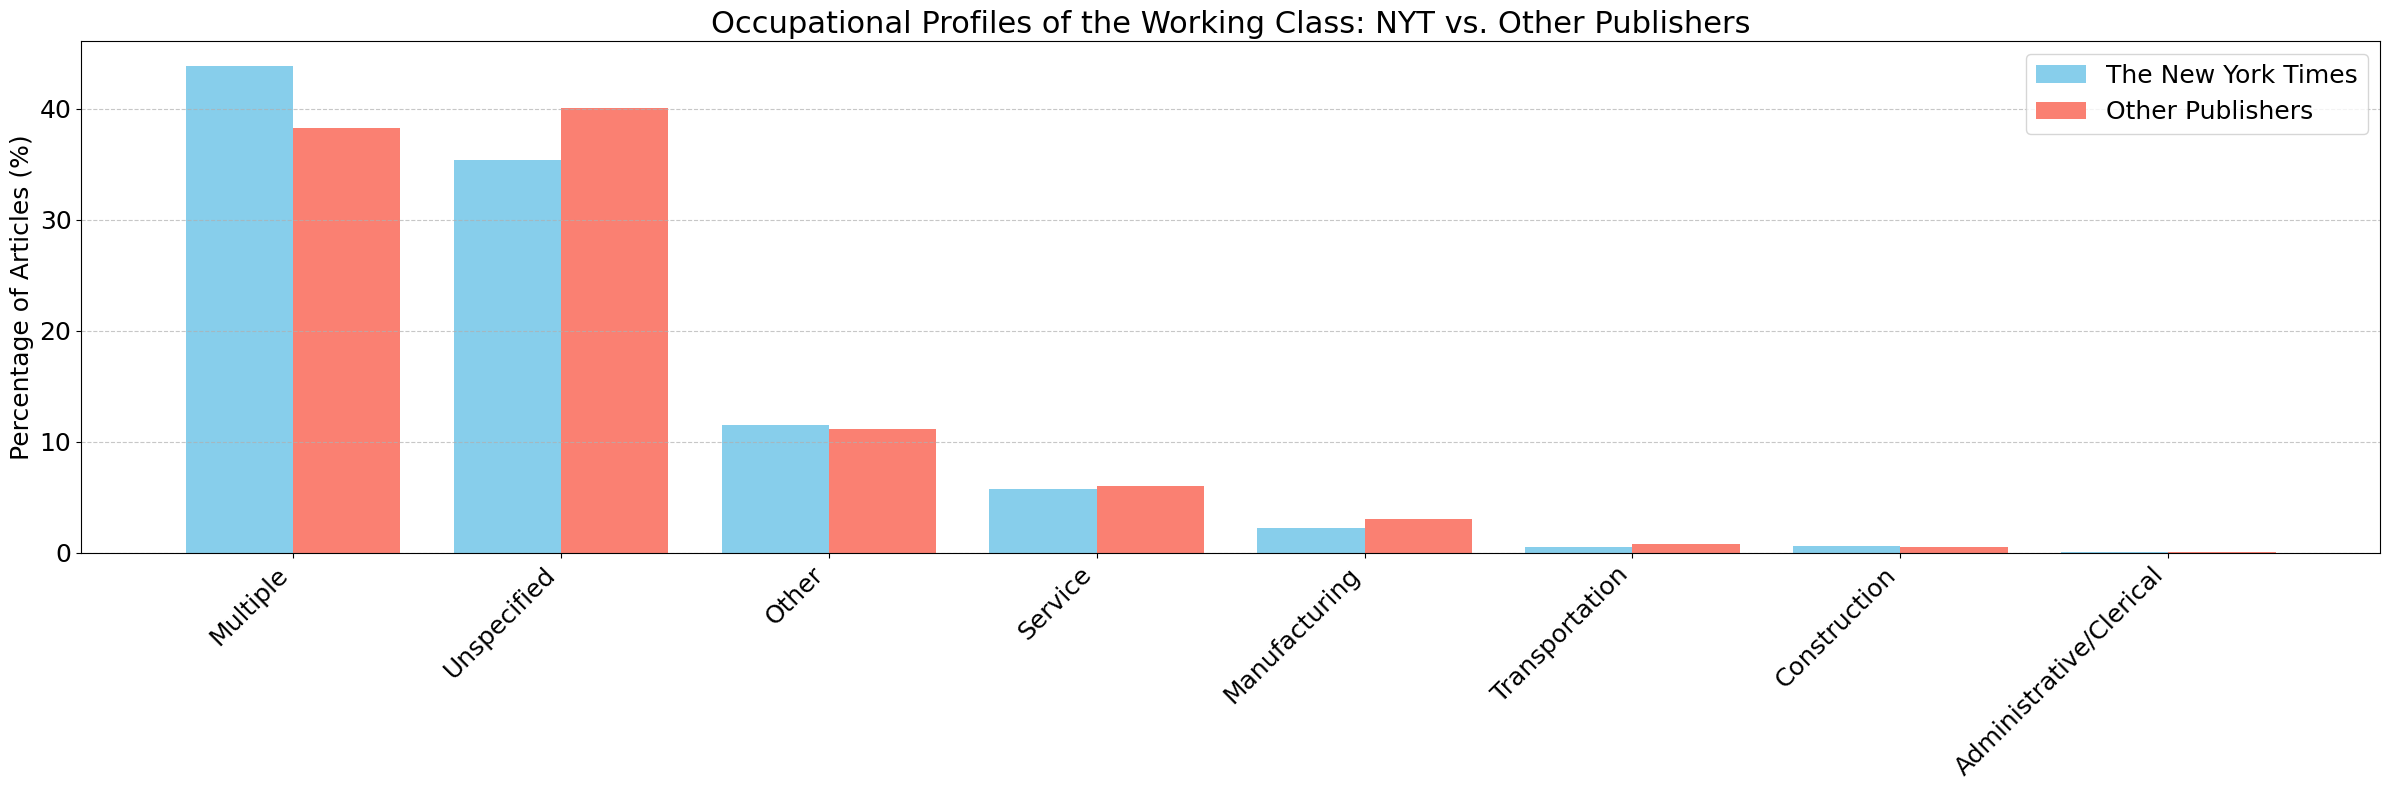

In [49]:
nyt_series = df_articles_with_results[nyt_mask]['occupations_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['occupations_stand_flat']


title = "Occupational Profiles of the Working Class: NYT vs. Other Publishers"
filename = "../plots/comparison_occupations.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

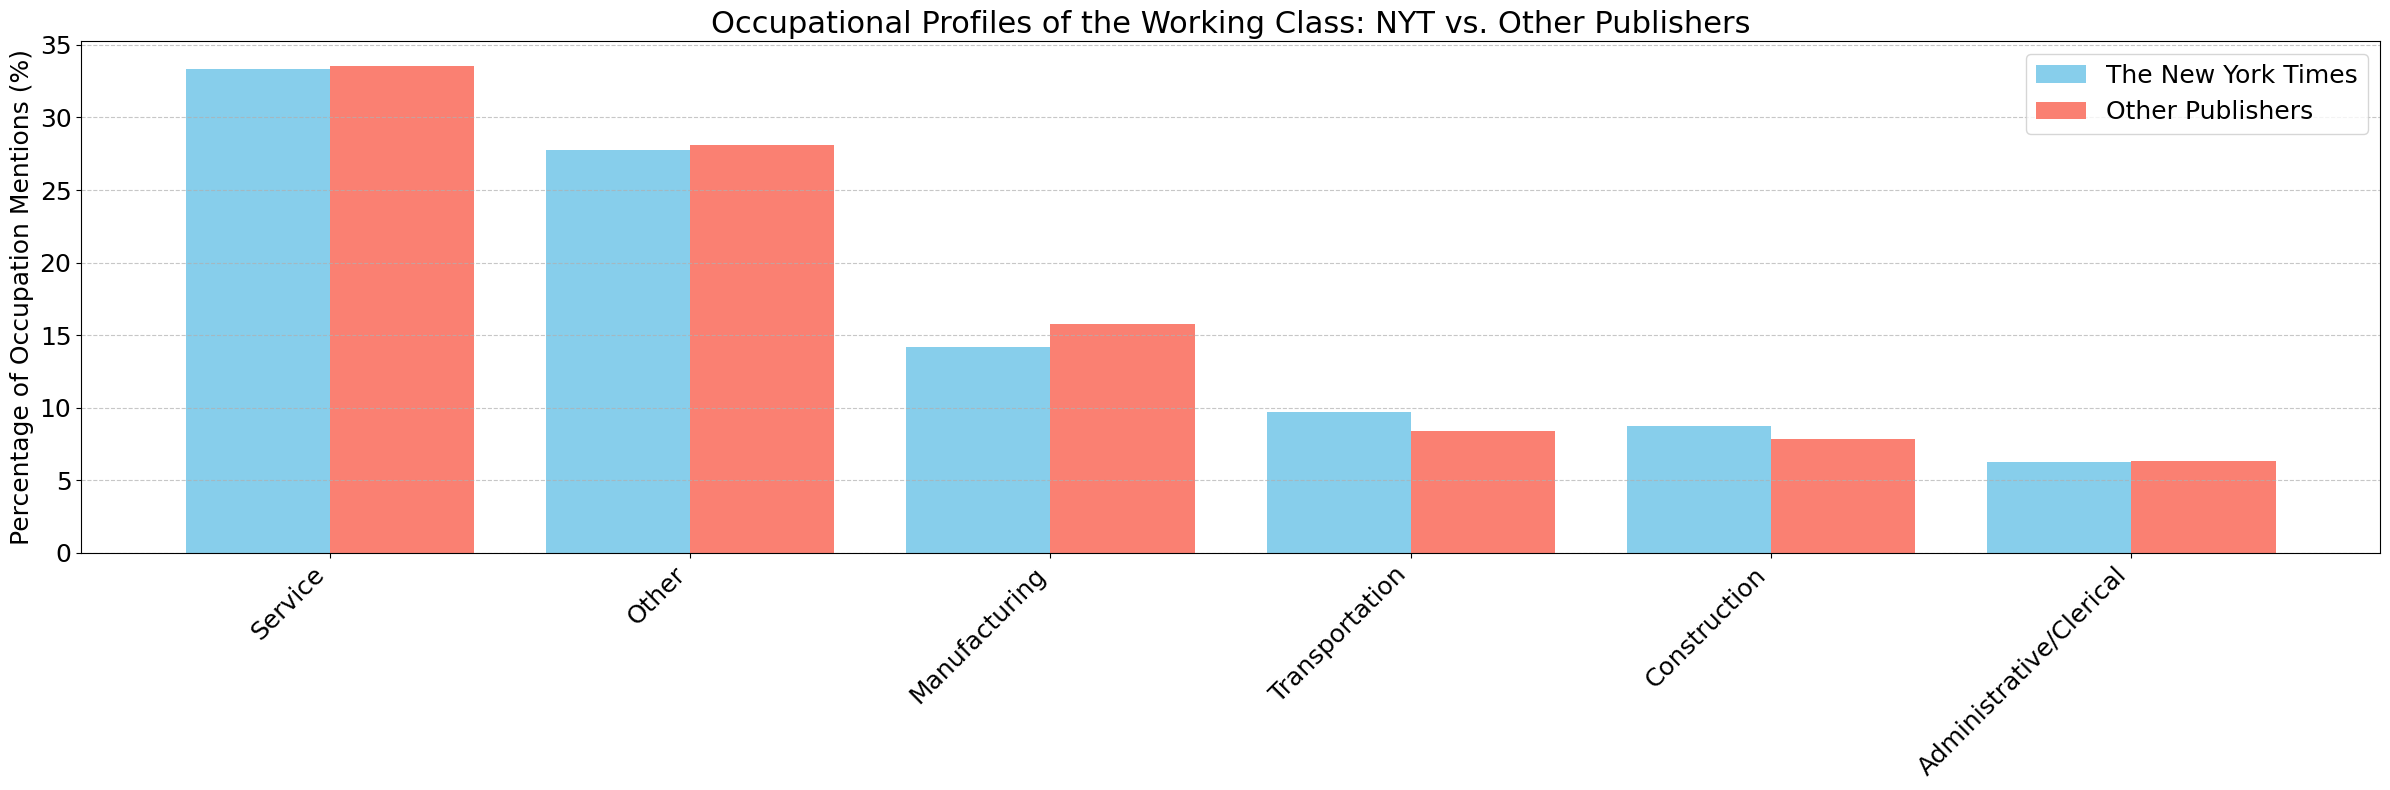

In [50]:
all_occupations_nyt = flatten(df_articles_with_results[nyt_mask]["occupations_stand"])
all_occupations_other = flatten(df_articles_with_results[~nyt_mask]["occupations_stand"])

title = "Occupational Profiles of the Working Class: NYT vs. Other Publishers"
filename = "../plots/comparison_occupations_all.png"

compare_histograms(all_occupations_nyt, all_occupations_other, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True, ylabel = "Percentage of Occupation Mentions (%)")

In [51]:
df_articles_with_results["occupations_stand"]

0        [Transportation, Manufacturing, Construction, ...
1                                                  [Other]
2                                                       []
3                                                       []
4                                                  [Other]
                               ...                        
13735                                                   []
13736                                      [Manufacturing]
13737                       [Construction, Other, Service]
13738                                                   []
13739                                            [Service]
Name: occupations_stand, Length: 13740, dtype: object

To do (after LLM big run):

* Review remaining "Other" values

* Only show occupation mentions

* Time trends for occupational mentions

In [52]:
other_occupation_df = df_articles_with_results.loc[df_articles_with_results['occupations_stand_flat'] == "Other"]
examples_other = other_occupation_df['occupations'].head(20)
examples_other = [item for sublist in examples_other for item in sublist]
examples_other = [i for i in examples_other if standardize_occupation([i], occupation_categories) == ["Other"]]
examples_other

['Other: Welder',
 'Other: Homemaker',
 'Other: drug dealers',
 'Other: squatters/homeless youth',
 'Other: gravedigger (working-class voice)',
 'Other: Farming',
 'Other: Business owner',
 'Other: Senior citizen (retired)',
 'Other: industrial workers/working-class family (factory/industrial context)',
 'Other: police (local police force)',
 'Other: hospitality/bistro workers (owner and association members likely city residents who grow grapes)',
 'Other: firefighters',
 "Other: farming (farmer's son), Other: taxi driver, Other: teaching (associate professor of physics), Other: university/academic positions",
 'Other: property renovator',
 'Other: tutor',
 'Other: working-class (generic)',
 'Other: Hairdressing (apprentice)',
 'Other: Poultry industry workers',
 'Other: cooperative housing residents/workers implied (working-class families)',
 'Other: blue-collar (working-class)',
 'Other: Blue-collar/manual jobs (implied)',
 'Other: state enterprise workers / industrial workers (impli

Questions for Elena:

* The "other" category appears often. Above are some examples of "Other" occupations (as identified by the LLM) - should they belong to one other defined categories? do we need additional categories?

In [53]:
var = 'occupations_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


<a id="race-ethnicity"></a>
### 3.3. Race/Ethnicity  

[⬆ Return to Top](#table-of-contents) 

What racial or ethnic backgrounds are identified for this working-class group?  

In [54]:
race_ethnicity_categories = ['White', 'Black or African American',
                             'American Indian or Alaska Native', 'Asian', 'Native Hawaiian or Other Pacific Islander']

In [55]:
def standardize_race_ethnicity(val_list):
    stand_list = []
    for val in val_list:
        val = val.lower()
        if val == "na":
            continue    
        if "black" in val or "african american" in val:
            stand_list.append("Black or African American")
        elif "american indian" in val or "alaska native" in val:
            stand_list.append('American Indian or Alaska Native')
        elif "asian" in val:
            stand_list.append("Asian")
        elif "native hawaiian" in val or "other pacific islander" in val:
            stand_list.append('Native Hawaiian or Other Pacific Islander')
        elif "white" in val:
            stand_list.append("White")
        else:
            stand_list.append("Other")
    return stand_list
        
            

In [56]:
df_articles_with_results['race_ethnicity_list'] = df_articles_with_results['race_ethnicity'].apply(lambda x: re.split(';|,', x))
df_articles_with_results['race_ethnicity_stand'] = df_articles_with_results['race_ethnicity_list'].apply(standardize_race_ethnicity)

df_articles_with_results['race_ethnicity_stand_flat'] = df_articles_with_results['race_ethnicity_stand'].apply(flatten_column)

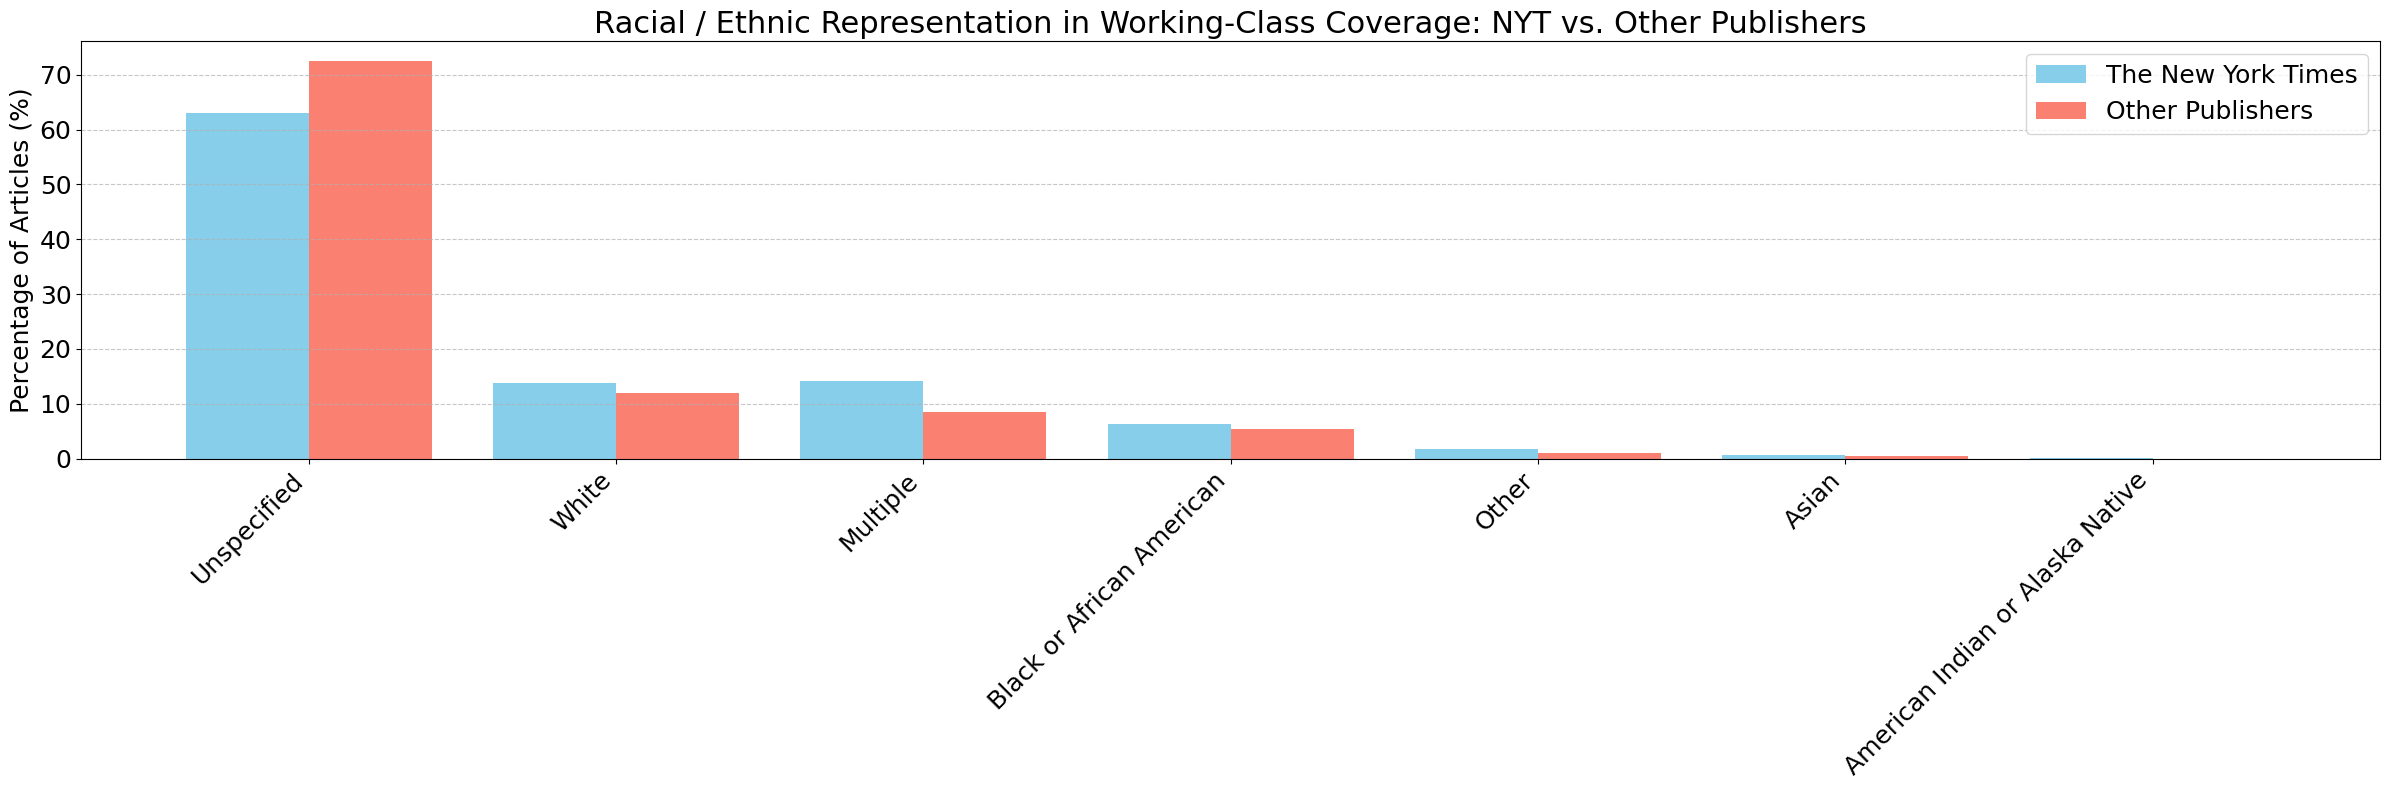

In [57]:
nyt_series = df_articles_with_results[nyt_mask]['race_ethnicity_stand_flat']
other_series = df_articles_with_results[~nyt_mask]['race_ethnicity_stand_flat']

title = 'Racial / Ethnic Representation in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_race_ethnicity.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [58]:
var =  'race_ethnicity_stand_flat'
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


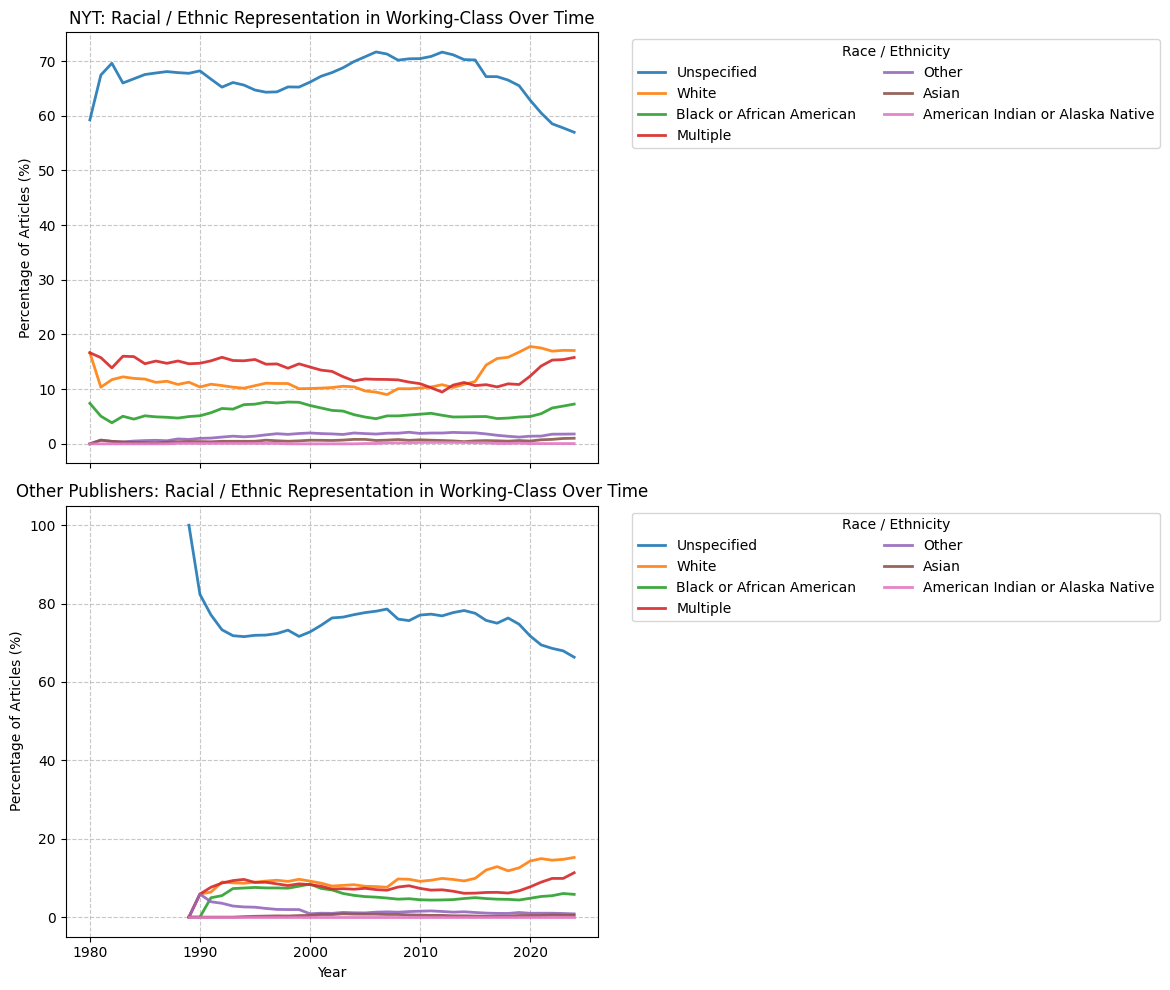

In [59]:
variable = 'race_ethnicity_stand_flat'
filename = "../plots/comparison_race_ethnicity_time_chart.png"
title = 'Racial / Ethnic Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results, nyt_mask, variable, title, filename, variable_label="Race / Ethnicity", smooth_window=10)

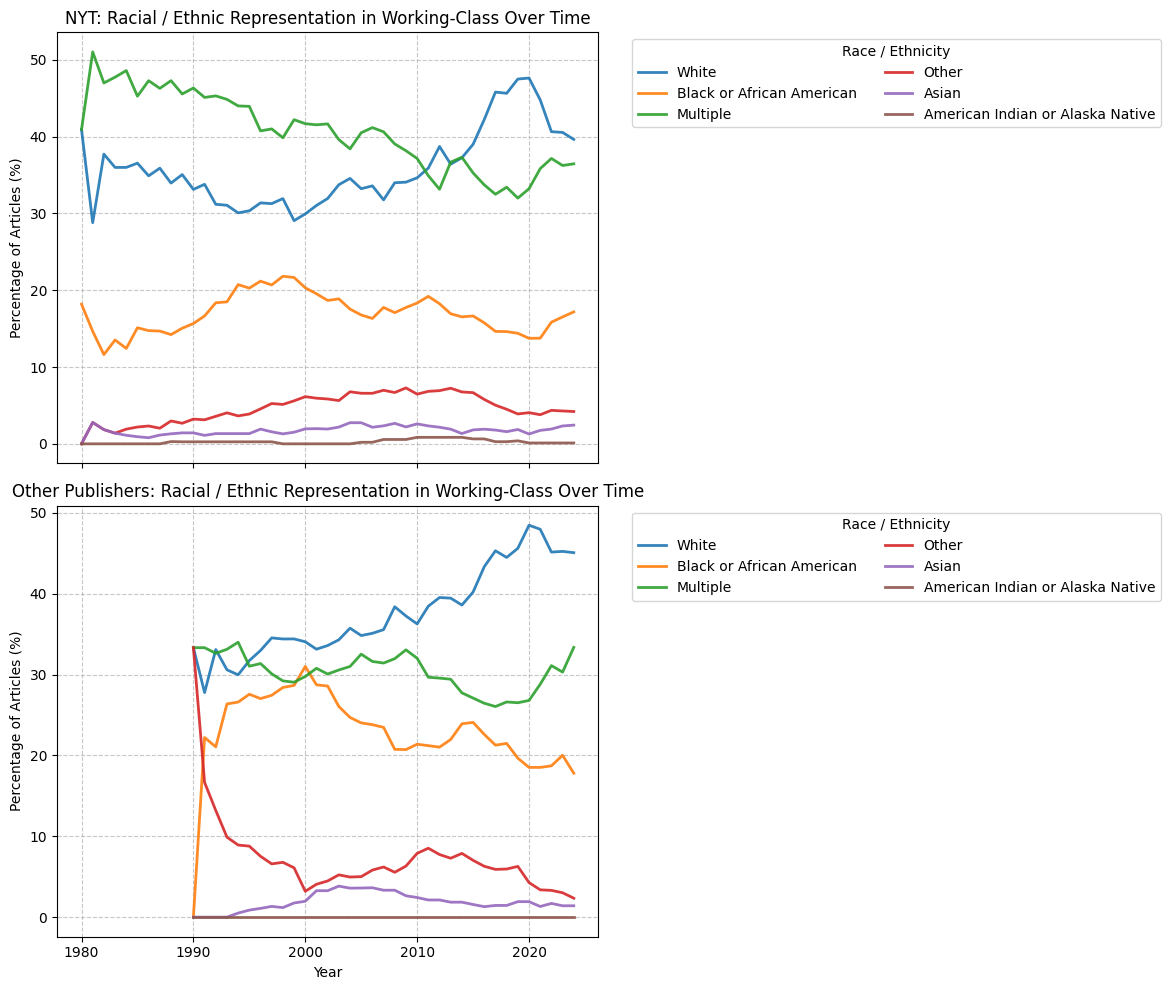

In [60]:
exclude = 'Unspecified'

df_articles_with_results_filter = df_articles_with_results.loc[df_articles_with_results['race_ethnicity_stand_flat'] != "Unspecified"]

nyt_mask_filter = df_articles_with_results_filter["publisher"] == "New York Times"
#year_mask_filter = df_articles_with_results_filter["year"] > 1991


variable = 'race_ethnicity_stand_flat'
filename = "../plots/comparison_race_ethnicity_time_chart.png"
title = 'Racial / Ethnic Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results_filter, nyt_mask_filter, variable, title, filename, variable_label="Race / Ethnicity", smooth_window=10)

<a id="gender"></a>
### 3.4. Gender  

[⬆ Return to Top](#table-of-contents)  

What is the gender composition of the working-class group?  

In [61]:
# Note: already flat

#def standardize_value(value, categories):
 #   if value == "NA":
  #      return "Unspecified"
   # for cat in categories:
    #    if cat.lower() in value.lower():
     #       return cat
    #return "Other"

#gender_categories = ["Mostly Women", "Mostly Men", "Mixed", "Nonbinary"] # Plus Unspecified

In [62]:
def standardize_gender(value):
    if value == "NA" or "Not specified" in value:
        return "Unspecified"
    value = value.lower()
    for other_cat in ["non-binary", "lgbtq", "lesbian", "gay", "transgender", "trans", "queer"]:
        if other_cat in value:
            return "Other"
    if 'mixed' in value:
        return "Multiple"
    elif "mostly women" in value:
        return "Women"
    elif "mostly men" in value:
        return "Men"
    elif "female" in value or "woman" in value or "women" in value:
        return "Women"
    elif "male" in value or "man" in value or "men" in value or "boys" in value:
        return "Men"
    return "Other"

In [63]:
df_articles_with_results["gender_stand"] = df_articles_with_results["gender"].apply(standardize_gender)

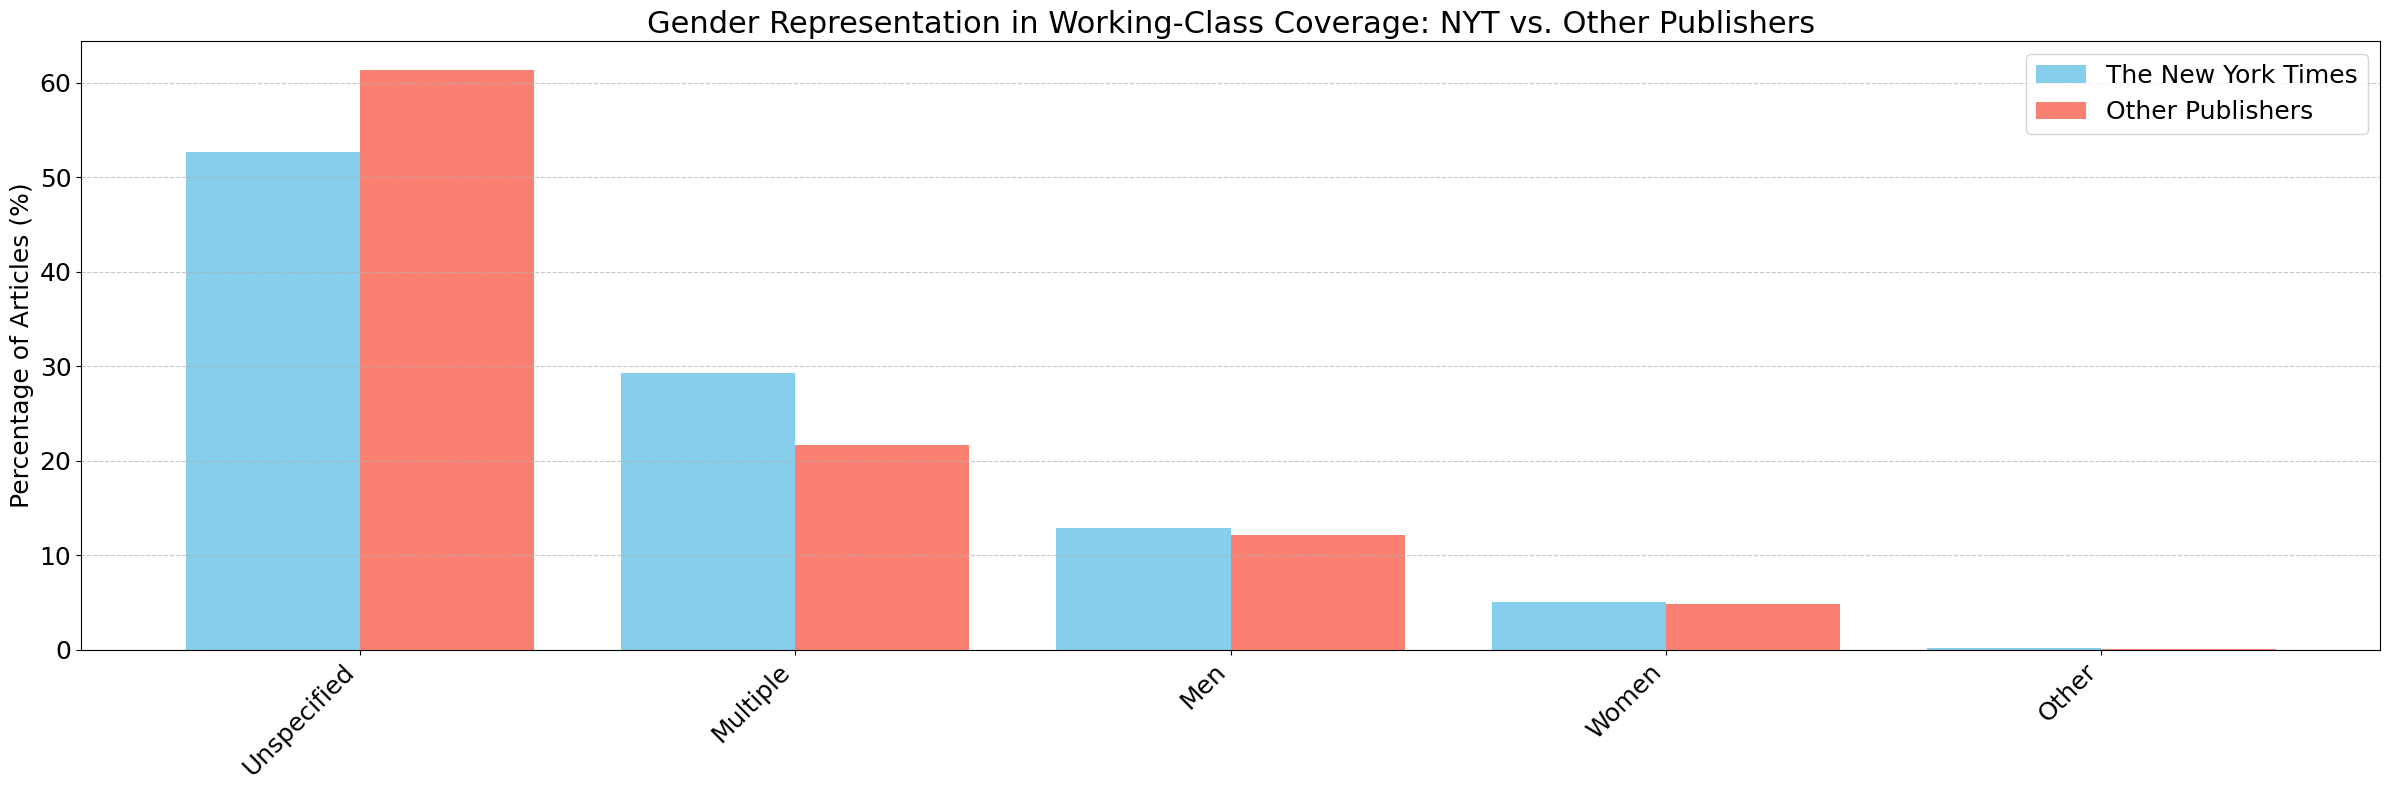

In [64]:
nyt_series = df_articles_with_results[nyt_mask]['gender_stand']
other_series = df_articles_with_results[~nyt_mask]['gender_stand']

title = 'Gender Representation in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_gender.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [65]:
var = 'gender_stand'
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


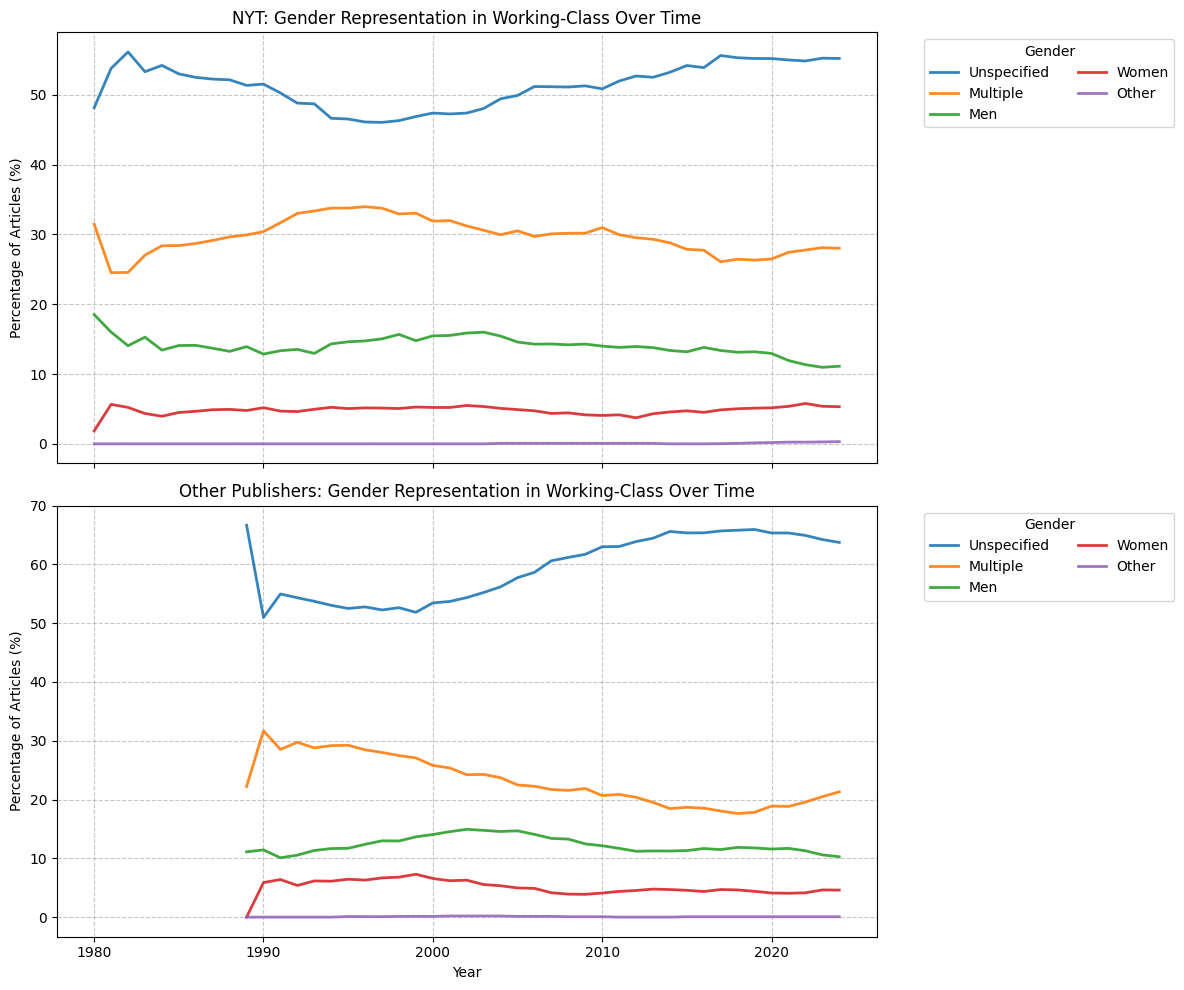

In [66]:
variable = 'gender_stand'
filename = "../plots/comparison_gender_time_chart.png"
title = 'Gender Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results, nyt_mask, variable, title, filename, variable_label="Gender", smooth_window=10)

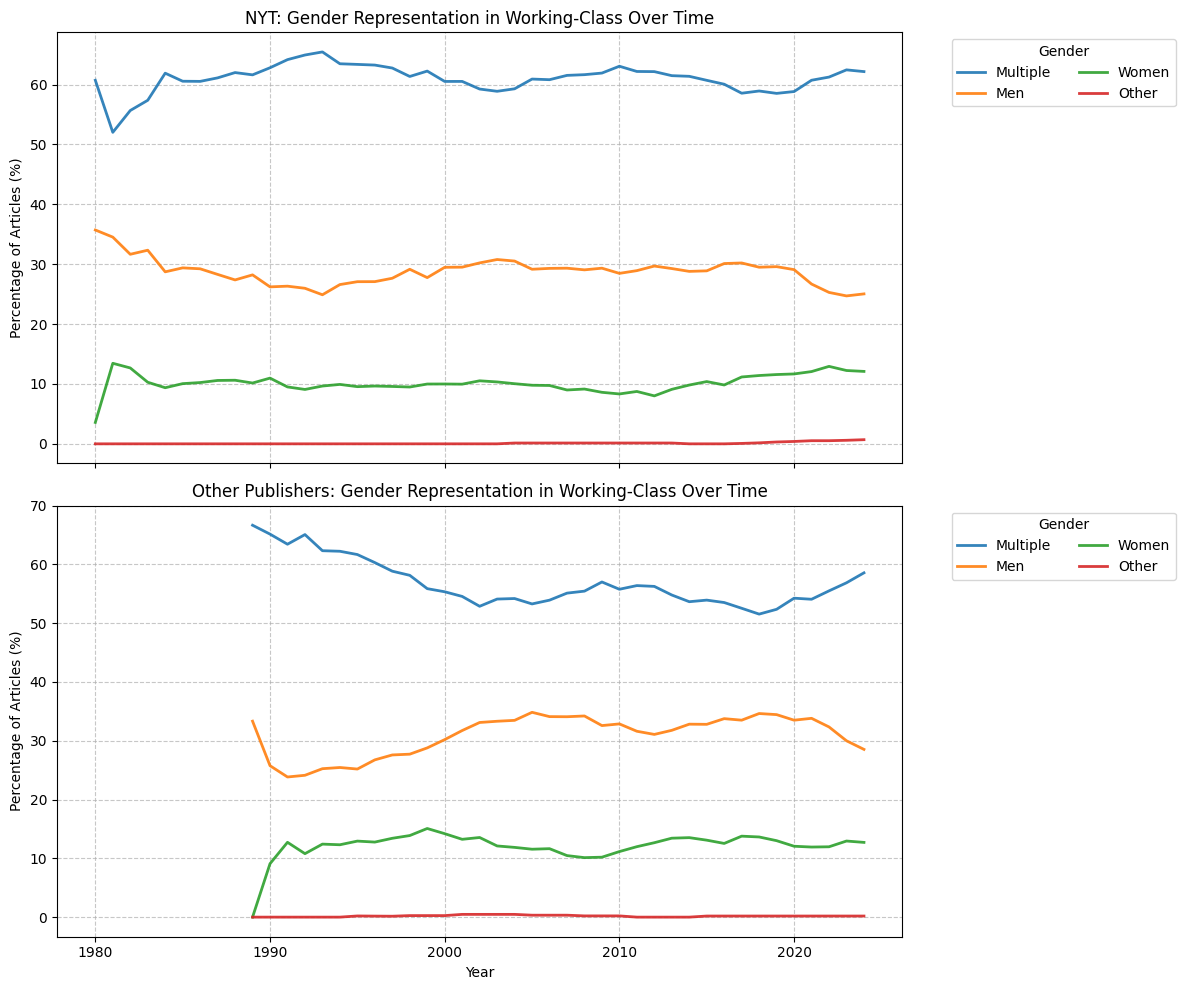

In [67]:
exclude = ['Unspecified'] # ['Unspecified', 'Mixed']

df_articles_with_results_filter = df_articles_with_results.loc[~df_articles_with_results['gender_stand'].isin(exclude)]

nyt_mask_filter = df_articles_with_results_filter["publisher"] == "New York Times"
#year_mask_filter = df_articles_with_results_filter["year"] > 1991




variable = 'gender_stand'
filename = "../plots/comparison_gender_time_chart_filter.png"
title = 'Gender Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results_filter, nyt_mask_filter, variable, title, filename, variable_label="Gender", smooth_window=10)


<a id="immigration-status"></a>
### 3.6. Immigration Status  

[⬆ Return to Top](#table-of-contents)  


What is the immigration status of the working-class group? Determine whether the working-class group includes any immigrants.

* Output "Immigrant" if at least one individual in the group is an immigrant.

* Output "Not immigrant" if all individuals are non-immigrants.

* Output "NA" if there is no information available about the immigration status of the workers.


In [68]:
df_articles_with_results['immigration_status'].value_counts()

immigration_status
NA                                                                                                         12309
Immigrant                                                                                                   1370
Not immigrant                                                                                                 53
Includes immigrants                                                                                            4
Immigrant or Not immigrant (both mentioned)                                                                    1
Includes immigrants (Immigrant)                                                                                1
Immigrant (the article notes working alongside immigrants and mentions Filipino and Hispanic coworkers)        1
Immigrant (migrant camps in California's Central Valley indicate presence of immigrants)                       1
Name: count, dtype: int64

In [69]:
def standardize_immigration_status(value):
    value = value.lower()
    if value == "na":
        return "Unspecified"
    if "immigrant and not immigrant" in value:
        return "Immigrant"
    if "not immigrant" in value:
        return "Not Immigrant"
    if "immigrant" in value:
        return "Immigrant"
    return "Other"

In [70]:
df_articles_with_results['immigration_status_stand'] = df_articles_with_results['immigration_status'].apply(standardize_immigration_status)

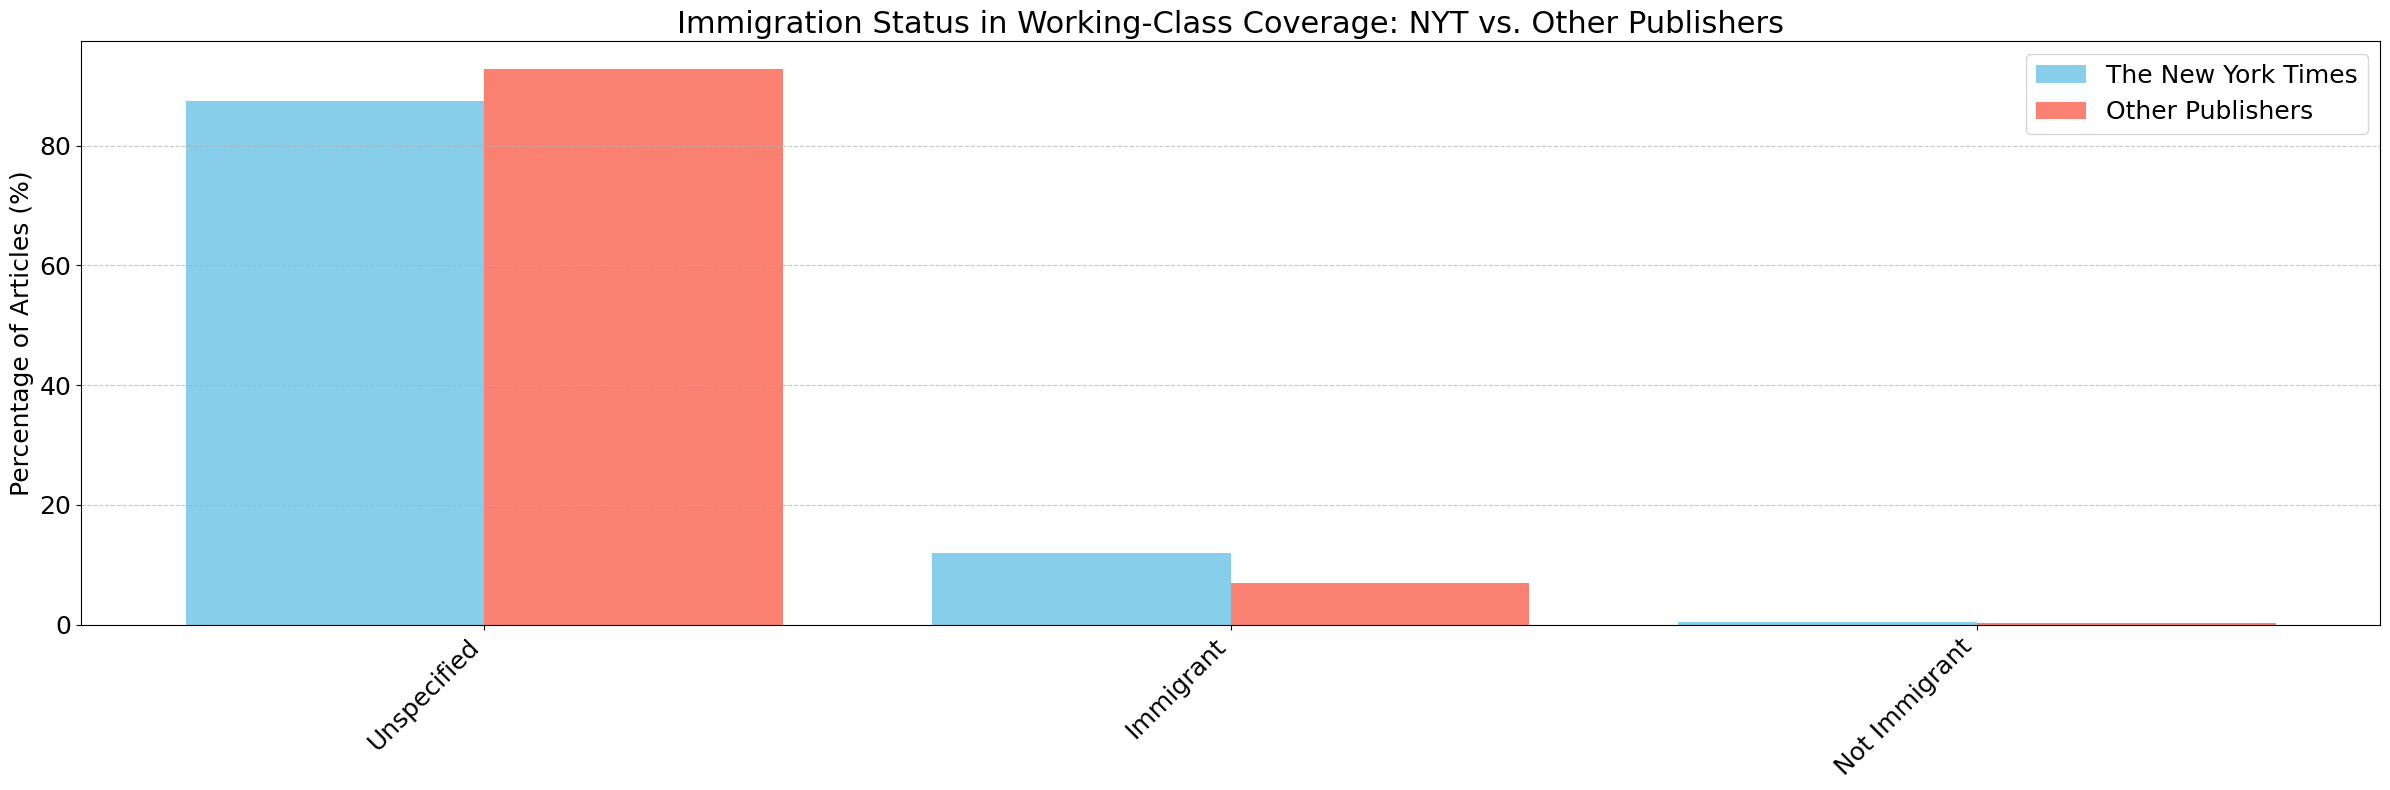

In [71]:
nyt_series = df_articles_with_results[nyt_mask]['immigration_status_stand']
other_series = df_articles_with_results[~nyt_mask]['immigration_status_stand']

title = 'Immigration Status in Working-Class Coverage: NYT vs. Other Publishers'
filename = "../plots/comparison_immigration.png"

compare_histograms(nyt_series, other_series, title, filename, label1='The New York Times', label2='Other Publishers', scale_counts=True, order_by_count=True)

In [72]:
var = "immigration_status_stand"
save_examples_to_folder(var, df_articles_with_results, examples_dir)

✅ Articles saved successfully.


In [73]:
df_articles_with_results['immigration_status_stand'].value_counts()

immigration_status_stand
Unspecified      12309
Immigrant         1377
Not Immigrant       54
Name: count, dtype: int64

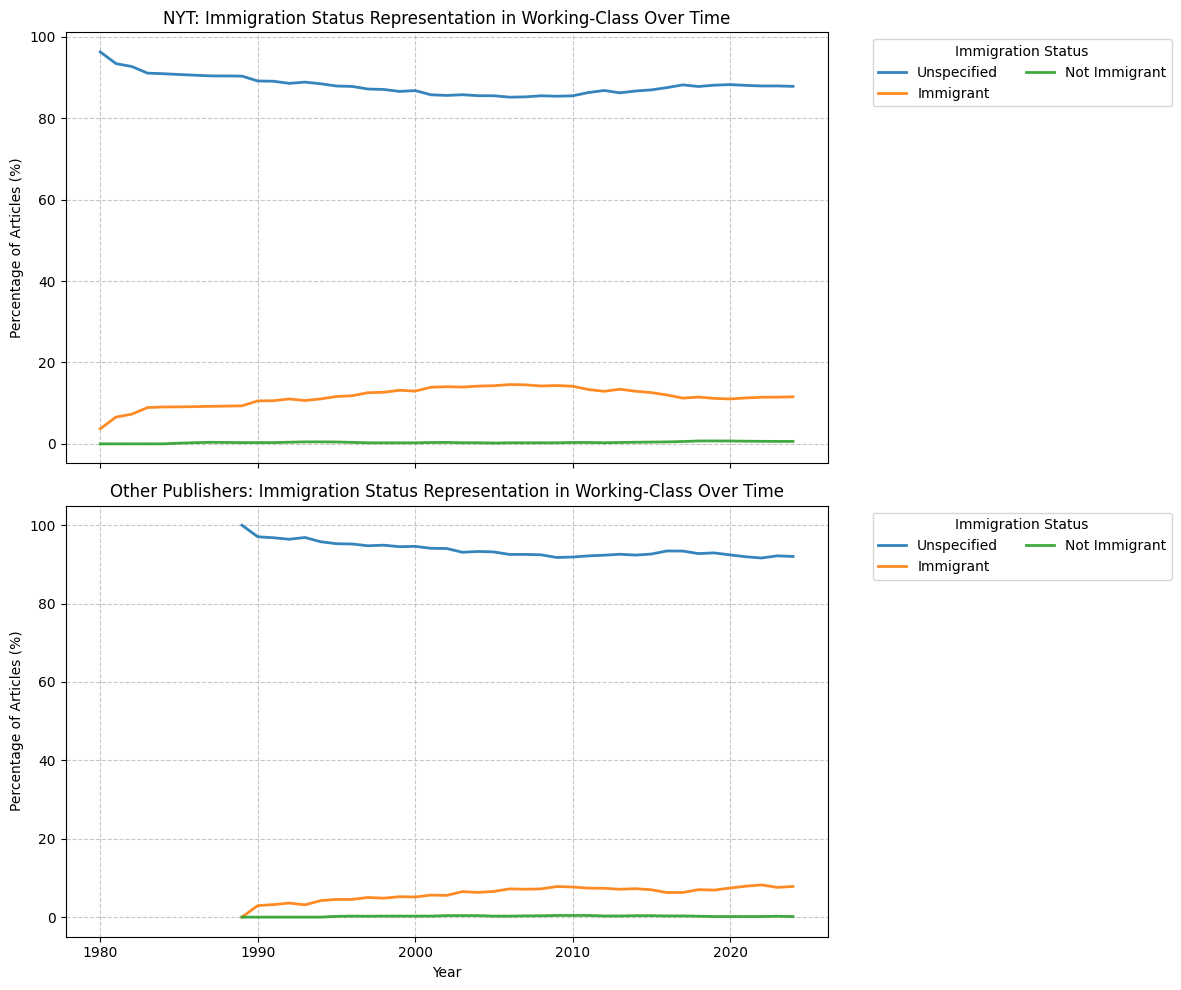

In [74]:


nyt_mask_filter = df_articles_with_results["publisher"] == "New York Times"

variable = 'immigration_status_stand'
filename = "../plots/comparison_immigration_time_chart.png"
title = 'Immigration Status Representation in Working-Class Over Time'
line_time_plot(df_articles_with_results, nyt_mask_filter, variable, title, filename, variable_label="Immigration Status", smooth_window=10)

<a id="conclusion"></a>
## 4. Conclusion


[⬆ Return to Top](#table-of-contents)

(TK: explain)

<a id="next-steps"></a>
## 5. Next Steps


[⬆ Return to Top](#table-of-contents)


TO DO:

Next:

* Discuss and confirm with Elena

* Run on full sample.


After extending to full sample):

* Remove smoothing window

* REview file names and variable_label in time charts


<a id="reproducibility"></a>
## 6. Reproducibility


[⬆ Return to Top](#table-of-contents)

(TK: explain)

In [75]:
import pandas as pd
import matplotlib
import openai
import wordcloud
import ast

print("pandas==", pd.__version__)
print("matplotlib==", matplotlib.__version__)
print("openai==", openai.__version__)
print("wordcloud==", wordcloud.__version__)

pandas== 2.2.3
matplotlib== 3.10.1
openai== 1.70.0
wordcloud== 1.9.4


<a id="bibliography"></a>

## 7. Bibliography

[⬆ Return to Top](#table-of-contents)

* Census race and ethnicity categories: https://www.census.gov/topics/population/race/about.html